# Kansas Economic and Workforce Trends Analysis

## Project Goal

This project analyzes economic and workforce conditions across all 105 Kansas counties using data from the U.S. Census Bureau American Community Survey (ACS) and the Bureau of Labor Statistics (BLS) Local Area Unemployment Statistics (LAUS).

The analysis focuses on county-level differences in:

- Population
- Median household income
- Labor force participation
- Unemployment
- Poverty
- Educational attainment

The project also examines relationships among these indicators using correlation analysis, SQL queries, and multiple linear regression.

## Main Research Question

How do economic and workforce conditions vary across Kansas counties, and which factors are associated with higher or lower unemployment rates?


## Data Sources

### U.S. Census Bureau — American Community Survey (ACS) 5-Year Estimates, 2024

The Census ACS data provides county-level demographic and socioeconomic indicators used in this project, including:

- Total population
- Median household income
- Civilian labor force
- Population age 16 and older
- Unemployed population
- Poverty status
- Population age 25 and older
- Bachelor's, master's, professional, and doctorate degree attainment

These variables were retrieved through the Census API for all 105 Kansas counties.

### Bureau of Labor Statistics — Local Area Unemployment Statistics (LAUS), 2024 Annual Averages

The BLS LAUS county dataset provides:

- Labor force
- Employment
- Unemployment
- Unemployment rate

The national county file was filtered to Kansas using State FIPS Code 20.

### Geographic Matching

Census and BLS data were merged using:

- State FIPS code
- County FIPS code

This produced a final dataset containing all 105 Kansas counties.

## Data Preparation

The Census ACS and BLS LAUS datasets required several preparation steps before analysis.

### Census Data Preparation

The Census API data was processed to:

- Rename Census variable codes into understandable column names.
- Convert numeric variables from text to numeric data types.
- Calculate labor force participation rate.
- Calculate unemployment rate.
- Calculate poverty rate.
- Combine bachelor's, master's, professional, and doctorate degree counts.
- Calculate the percentage of adults age 25 and older with a bachelor's degree or higher.

### BLS Data Preparation

The BLS LAUS county file was processed to:

- Correct the Excel header structure.
- Filter the national dataset to Kansas counties.
- Select labor force, employment, unemployment, and unemployment rate measures.
- Standardize State and County FIPS codes.

### Data Integration and Validation

The Census and BLS datasets were merged using State and County FIPS codes.

The final dataset contained:

- **105 Kansas counties**
- **26 variables**
- **0 duplicate counties**
- **0 missing values in the analyzed variables**

FIPS codes were used for the merge instead of county names because the Census and BLS datasets use different county-name formats.

import pandas as pd

# Load the final merged Kansas dataset
file_path = "../data/processed/kansas_economic_workforce_2024.csv"
df = pd.read_csv(file_path)

# Display the first five rows
df.head()







## Data Preparation

The Census ACS and BLS LAUS datasets required several preparation steps before analysis.

### Census Data Preparation

The Census API data was processed to:

- Rename Census variable codes into understandable column names.
- Convert numeric variables from text to numeric data types.
- Calculate labor force participation rate.
- Calculate unemployment rate.
- Calculate poverty rate.
- Combine bachelor's, master's, professional, and doctorate degree counts.
- Calculate the percentage of adults age 25 and older with a bachelor's degree or higher.

### BLS Data Preparation

The BLS LAUS county file was processed to:

- Correct the Excel header structure.
- Filter the national dataset to Kansas counties.
- Select labor force, employment, unemployment, and unemployment rate measures.
- Standardize State and County FIPS codes.

### Data Integration and Validation

The Census and BLS datasets were merged using State and County FIPS codes.

The final dataset contained:

- **105 Kansas counties**
- **26 variables**
- **0 duplicate counties**
- **0 missing values in the analyzed variables**

FIPS codes were used for the merge instead of county names because the Census and BLS datasets use different county-name formats.



In [2]:

import pandas as pd

# Load the final merged Kansas dataset
file_path = "../data/processed/kansas_economic_workforce_2024.csv"
df = pd.read_csv(file_path)

# Display the first five rows
df.head()



,county_name_census,population,median_household_income,civilian_labor_force,population_16_plus,unemployed_census,poverty_universe,below_poverty,population_25_plus,bachelors_degree,...,unemployment_rate_census,poverty_rate,bachelors_or_higher,bachelors_or_higher_rate,county_name_bls,year,labor_force,employed,unemployed_bls,unemployment_rate_bls
0,"Allen County, Kansas",12483,60689,6269,9991,496,12018,1192,8477,1231,...,7.91,9.92,1902,22.44,"Allen County, KS",2024.0,6051.0,5813.0,238.0,3.9
1,"Anderson County, Kansas",7834,70614,3710,5983,152,7724,853,5214,426,...,4.10,11.04,728,13.96,"Anderson County, KS",2024.0,3782.0,3655.0,127.0,3.4
2,"Atchison County, Kansas",16208,61112,8170,13043,375,14574,1891,9846,1322,...,4.59,12.98,2149,21.83,"Atchison County, KS",2024.0,8115.0,7808.0,307.0,3.8
3,"Barber County, Kansas",4069,61926,2248,3237,28,3966,467,2774,597,...,1.25,11.78,756,27.25,"Barber County, KS",2024.0,2077.0,2015.0,62.0,3.0
4,"Barton County, Kansas",25097,58851,12424,19743,483,24591,3787,17024,2660,...,3.89,15.40,3690,21.68,"Barton County, KS",2024.0,12369.0,11942.0,427.0,3.5


In [3]:
# Check the size of the final dataset
print("Dataset shape:", df.shape)

# Check for duplicate counties
print("Duplicate counties:", df["county_fips"].duplicated().sum())

# Check missing values in the main analysis variables
analysis_columns = [
    "unemployment_rate_bls",
    "poverty_rate",
    "median_household_income",
    "bachelors_or_higher_rate",
    "labor_force_participation_rate"
]

print("\nMissing values:")
print(df[analysis_columns].isnull().sum())

Dataset shape: (105, 26)
Duplicate counties: 0

Missing values:
unemployment_rate_bls             0
poverty_rate                      0
median_household_income           0
bachelors_or_higher_rate          0
labor_force_participation_rate    0
dtype: int64


## Exploratory Data Analysis

The next step examines differences in unemployment across Kansas counties. Ranking counties by unemployment rate helps identify areas experiencing relatively higher and lower unemployment in the 2024 BLS LAUS data.


In [4]:
# Select county name and unemployment rate
unemployment_analysis = df[
    ["county_name_census", "unemployment_rate_bls"]
].copy()

# Rename columns for easier reading
unemployment_analysis.columns = [
    "County",
    "Unemployment Rate"
]

# Display the 10 counties with the highest unemployment rates
top_10_unemployment = unemployment_analysis.sort_values(
    by="Unemployment Rate",
    ascending=False
).head(10)

top_10_unemployment

,County,Unemployment Rate
5,"Bourbon County, Kansas",5.3
103,"Woodson County, Kansas",4.9
53,"Linn County, Kansas",4.9
17,"Cowley County, Kansas",4.3
30,"Geary County, Kansas",4.3
104,"Wyandotte County, Kansas",4.2
39,"Harvey County, Kansas",4.2
24,"Elk County, Kansas",4.2
102,"Wilson County, Kansas",4.1
52,"Lincoln County, Kansas",4.1


### Unemployment Findings

The county-level analysis shows meaningful variation in unemployment across Kansas.

- **Bourbon County** had the highest unemployment rate in the dataset at **5.3%**.
- **Woodson County** and **Linn County** followed at **4.9%**.
- Other counties with relatively high unemployment included Cowley, Geary, Wyandotte, Harvey, Elk, Wilson, and Lincoln counties.
- The average unemployment rate across the 105 Kansas counties was approximately **3.4%**.

These results show that statewide or average measures can hide important differences between individual counties. Examining county-level data makes it possible to identify areas experiencing relatively greater labor-market challenges.

## Correlation Analysis

Correlation analysis is used to examine the direction and strength of relationships among the main economic and workforce indicators.

The analysis includes:

- Unemployment rate
- Poverty rate
- Median household income
- Bachelor's-or-higher educational attainment rate
- Labor-force participation rate

Correlation values range from **-1 to +1**. A positive value indicates that two variables tend to move in the same direction, while a negative value indicates that they tend to move in opposite directions. Correlation describes association and does not establish causation.

In [5]:
# Select variables for correlation analysis
correlation_columns = [
    "unemployment_rate_bls",
    "poverty_rate",
    "median_household_income",
    "bachelors_or_higher_rate",
    "labor_force_participation_rate"
]

# Calculate the correlation matrix
correlation_matrix = df[correlation_columns].corr().round(2)

# Display the correlation matrix
correlation_matrix

,unemployment_rate_bls,poverty_rate,median_household_income,bachelors_or_higher_rate,labor_force_participation_rate
unemployment_rate_bls,1.00,0.23,-0.28,-0.15,-0.35
poverty_rate,0.23,1.00,-0.49,-0.07,-0.05
median_household_income,-0.28,-0.49,1.00,0.40,0.40
bachelors_or_higher_rate,-0.15,-0.07,0.40,1.00,0.41
labor_force_participation_rate,-0.35,-0.05,0.40,0.41,1.00


In [6]:
correlation_columns = [
    "unemployment_rate_bls",
    "poverty_rate",
    "median_household_income",
    "bachelors_or_higher_rate",
    "labor_force_participation_rate"
]

correlation_matrix = df[correlation_columns].corr().round(2)

correlation_matrix


,unemployment_rate_bls,poverty_rate,median_household_income,bachelors_or_higher_rate,labor_force_participation_rate
unemployment_rate_bls,1.00,0.23,-0.28,-0.15,-0.35
poverty_rate,0.23,1.00,-0.49,-0.07,-0.05
median_household_income,-0.28,-0.49,1.00,0.40,0.40
bachelors_or_higher_rate,-0.15,-0.07,0.40,1.00,0.41
labor_force_participation_rate,-0.35,-0.05,0.40,0.41,1.00


## Multiple Linear Regression

A multiple linear regression model was used to examine how several county-level characteristics are associated with unemployment when considered together.

### Dependent Variable

- BLS unemployment rate

### Independent Variables

- Poverty rate
- Median household income
- Bachelor's-or-higher educational attainment rate
- Labor-force participation rate

The regression estimates the association between each predictor and unemployment while holding the other variables in the model constant.


In [7]:
import statsmodels.api as sm

# Define the dependent variable
y = df["unemployment_rate_bls"]

# Define the independent variables
X = df[
    [
        "poverty_rate",
        "median_household_income",
        "bachelors_or_higher_rate",
        "labor_force_participation_rate"
    ]
]

# Add the regression intercept
X = sm.add_constant(X)

# Fit the multiple linear regression model
model = sm.OLS(y, X).fit()

# Display the regression results
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     unemployment_rate_bls   R-squared:                       0.175
Model:                               OLS   Adj. R-squared:                  0.142
Method:                    Least Squares   F-statistic:                     5.291
Date:                   Tue, 29 Sep 2026   Prob (F-statistic):           0.000660
Time:                           00:57:35   Log-Likelihood:                -74.979
No. Observations:                    105   AIC:                             160.0
Df Residuals:                        100   BIC:                             173.2
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              5.6671      0.729      7.771      0.000       4.220       7.114
poverty_rate                       0.0275      0.016      1.738      0.085      -0.004       0.059
median_household_income        -3.608e-06   6.67e-06     -0.541      0.590   -1.68e-05    9.63e-06
bachelors_or_higher_rate           0.0016      0.008      0.192      0.848      -0.015       0.018
labor_force_participation_rate    -0.0378      0.012     -3.120      0.002      -0.062      -0.014
==============================================================================
Omnibus:                        8.535   Durbin-Watson:                   1.644
Prob(Omnibus):                  0.014   Jarque-Bera (JB):                8.355
Skew:                           0.587   Prob(JB):                       0.0153
Kurtosis:                       3.728   Cond. No.                     9.88e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.88e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Regression Findings

The multiple linear regression model was statistically significant overall (**F-test p = 0.000660**) and explained approximately **17.5% of the variation in county unemployment rates (R² = 0.175)**.

Among the four predictors:

- **Labor-force participation rate** was statistically significant (**coefficient = -0.0378, p = 0.002**). Holding the other variables constant, a 1 percentage-point increase in labor-force participation was associated with approximately a 0.038 percentage-point decrease in the unemployment rate.
- **Poverty rate** had a positive coefficient (**0.0275**) but was not statistically significant at the 5% level (**p = 0.085**).
- **Median household income** was not statistically significant (**p = 0.590**).
- **Bachelor's-or-higher educational attainment** was not statistically significant (**p = 0.848**).

The results suggest that labor-force participation had the clearest independent association with county unemployment among the variables included in this model. However, the relatively low R² indicates that much of the variation in county unemployment is associated with factors not included in this model.

These results describe statistical associations and should not be interpreted as evidence of causal relationships.


## Multicollinearity Diagnostic

Variance Inflation Factor (VIF) was used to check whether the independent variables in the regression model were highly correlated with one another.

High multicollinearity can make regression coefficients unstable and difficult to interpret. As a general diagnostic guideline, VIF values below 5 indicate that serious multicollinearity is not evident.


In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each regression variable
vif_data = pd.DataFrame()

vif_data["Variable"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Variable,VIF
0,const,1.000000
1,poverty_rate,1.381995
2,median_household_income,1.781832
3,bachelors_or_higher_rate,1.321090
4,labor_force_participation_rate,1.329461


### VIF Findings

The VIF results indicate that multicollinearity is not a major concern in the regression model.

- Poverty rate: **VIF = 1.38**
- Median household income: **VIF = 1.78**
- Bachelor's-or-higher rate: **VIF = 1.32**
- Labor-force participation rate: **VIF = 1.33**

All predictor VIF values are well below 5. This suggests that the independent variables are not excessively correlated with one another and can reasonably be included together in the regression model.

The regression output also reported a large condition number. Because median household income is measured in dollars while the other predictors are percentages, differences in variable scale can contribute to a large condition number. The VIF results provide additional evidence that severe predictor multicollinearity is not apparent.


## Visual Analysis

The following visualizations provide additional context for the relationships identified in the descriptive, correlation, and regression analyses.

The charts examine:

- Poverty and median household income
- Unemployment and labor-force participation
- Educational attainment and household income
- Counties with the highest unemployment rates


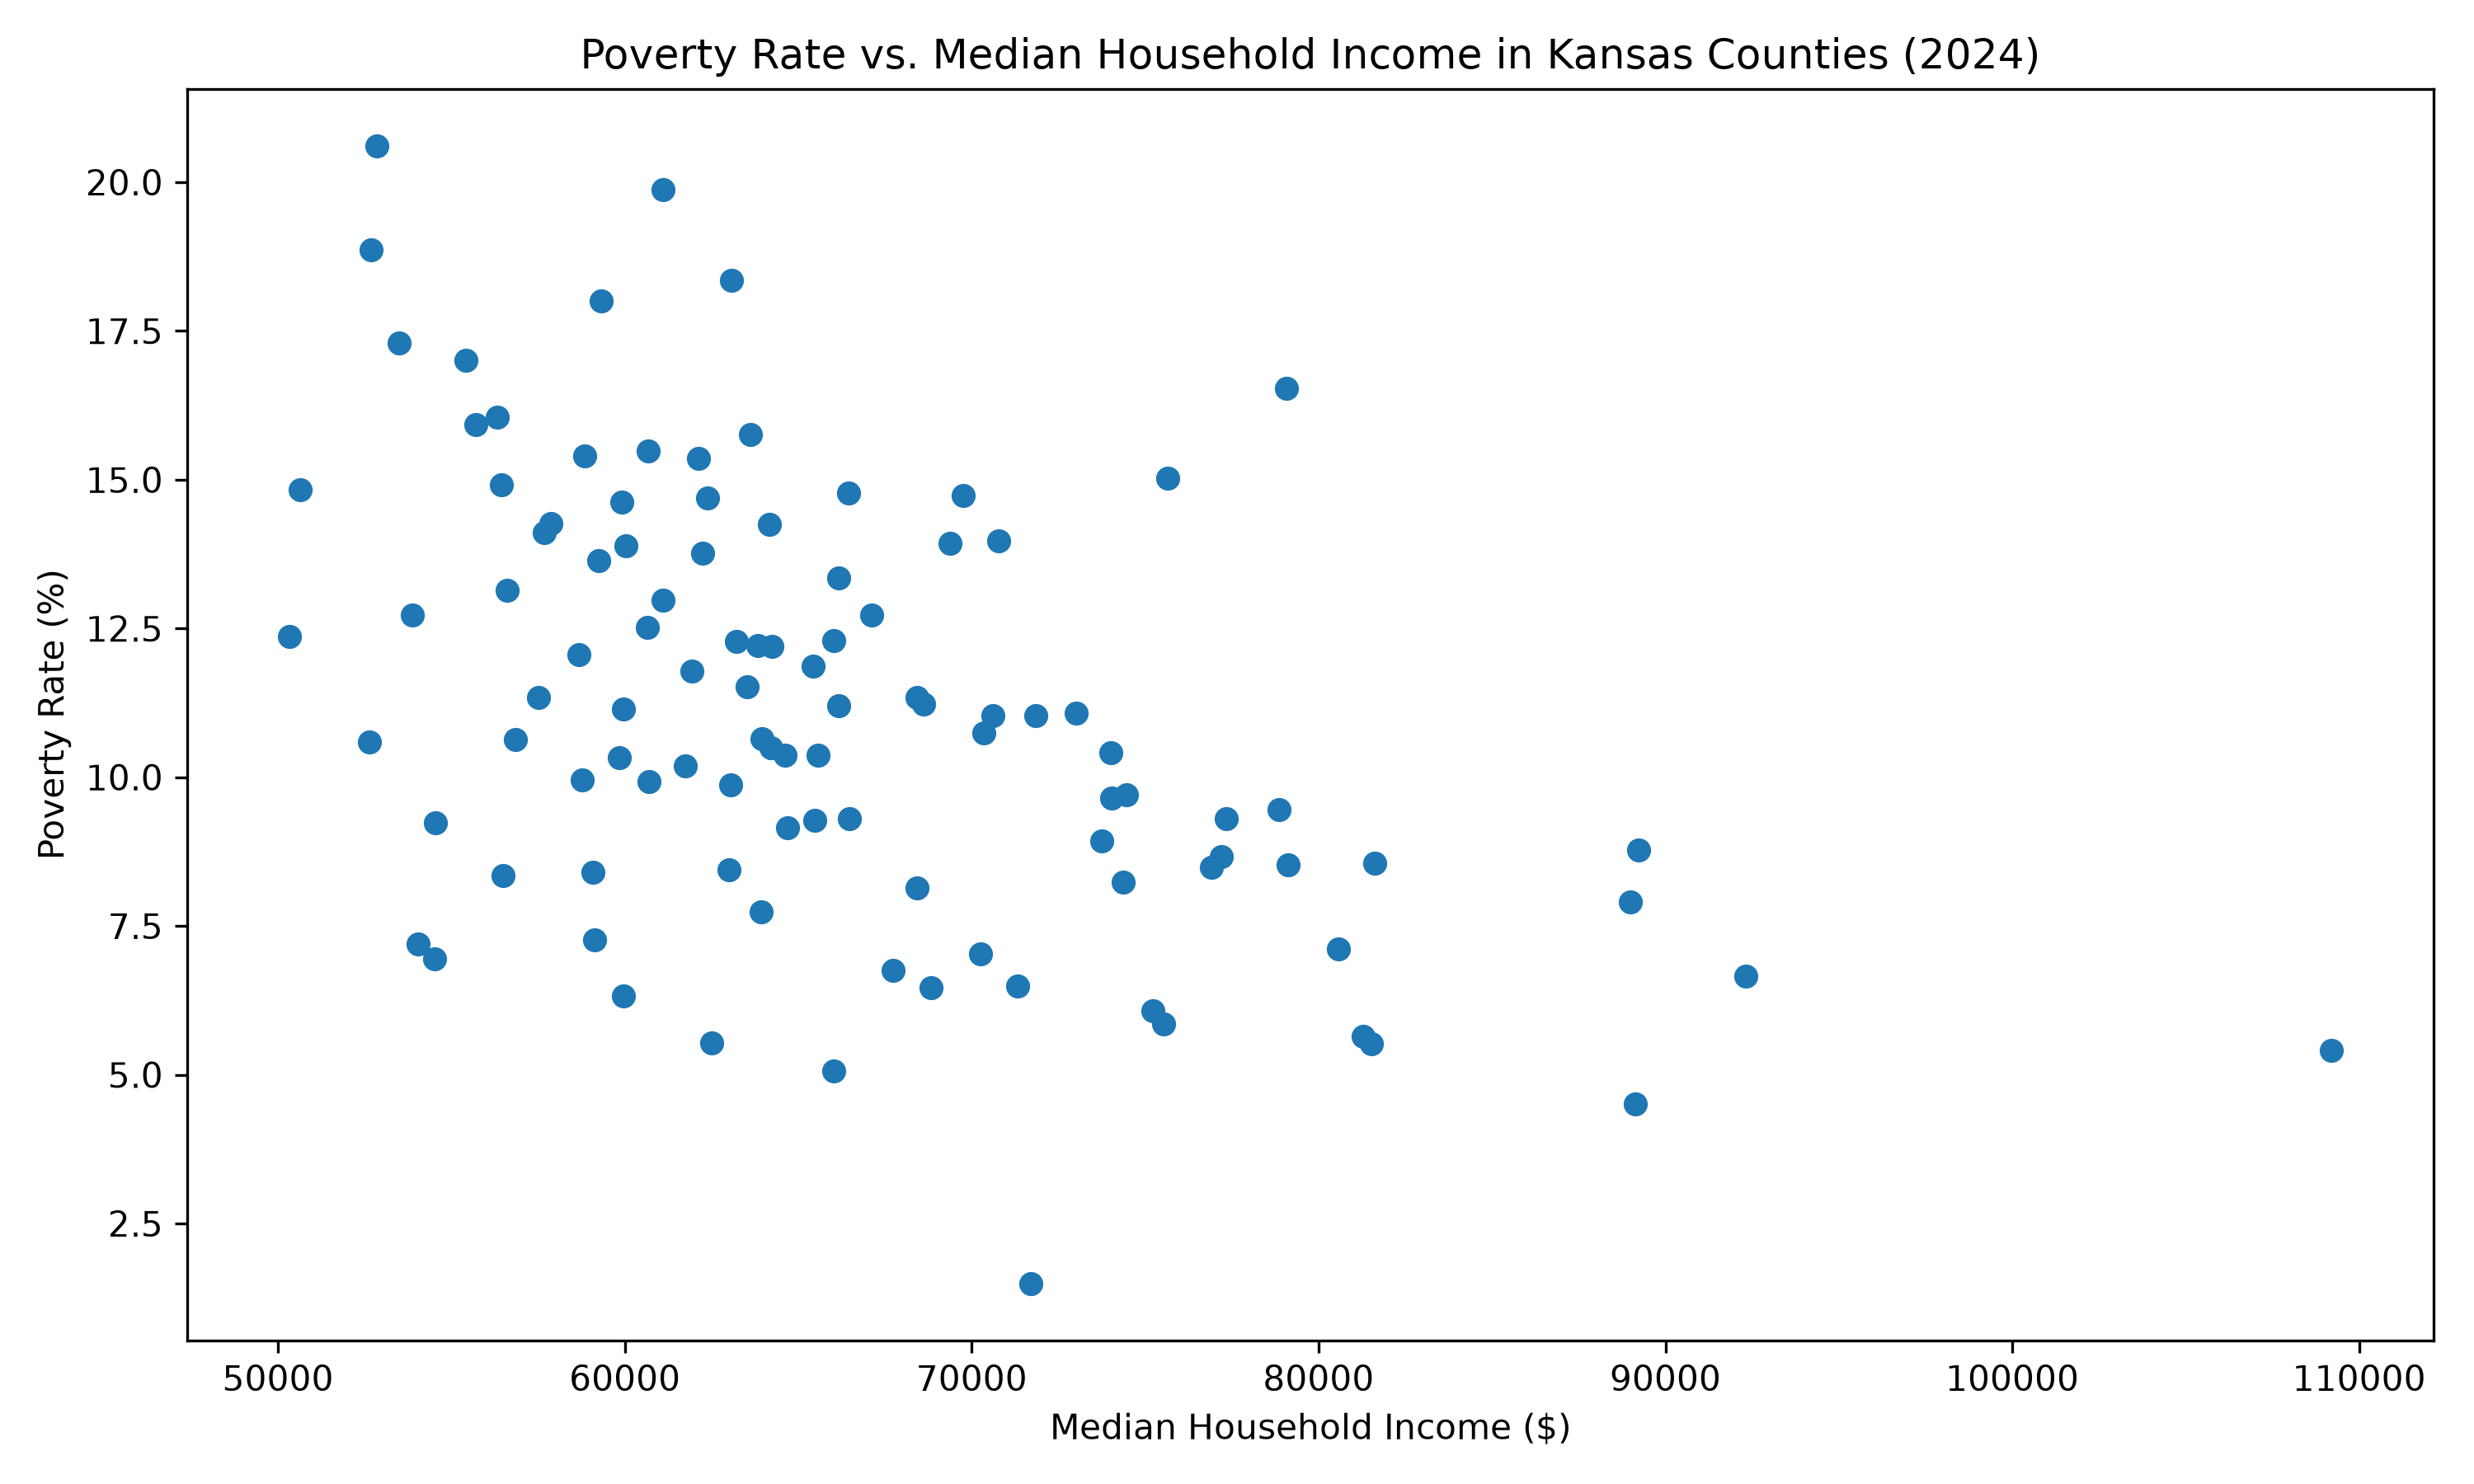

In [9]:
from IPython.display import Image, display

# Display poverty vs. median household income chart
display(
    Image(
        filename="../outputs/charts/poverty_vs_income.png"
    )
)

### Poverty and Household Income

The visualization shows a general negative relationship between poverty and median household income across Kansas counties.

This pattern is consistent with the correlation analysis, which found a correlation of **-0.49** between poverty rate and median household income. Counties with higher median household incomes generally tended to have lower poverty rates.

The relationship is not perfect, however, because counties with similar income levels can still have different poverty rates. This suggests that household income alone does not fully explain county-level differences in poverty.

The observed relationship represents an association and does not establish causation.

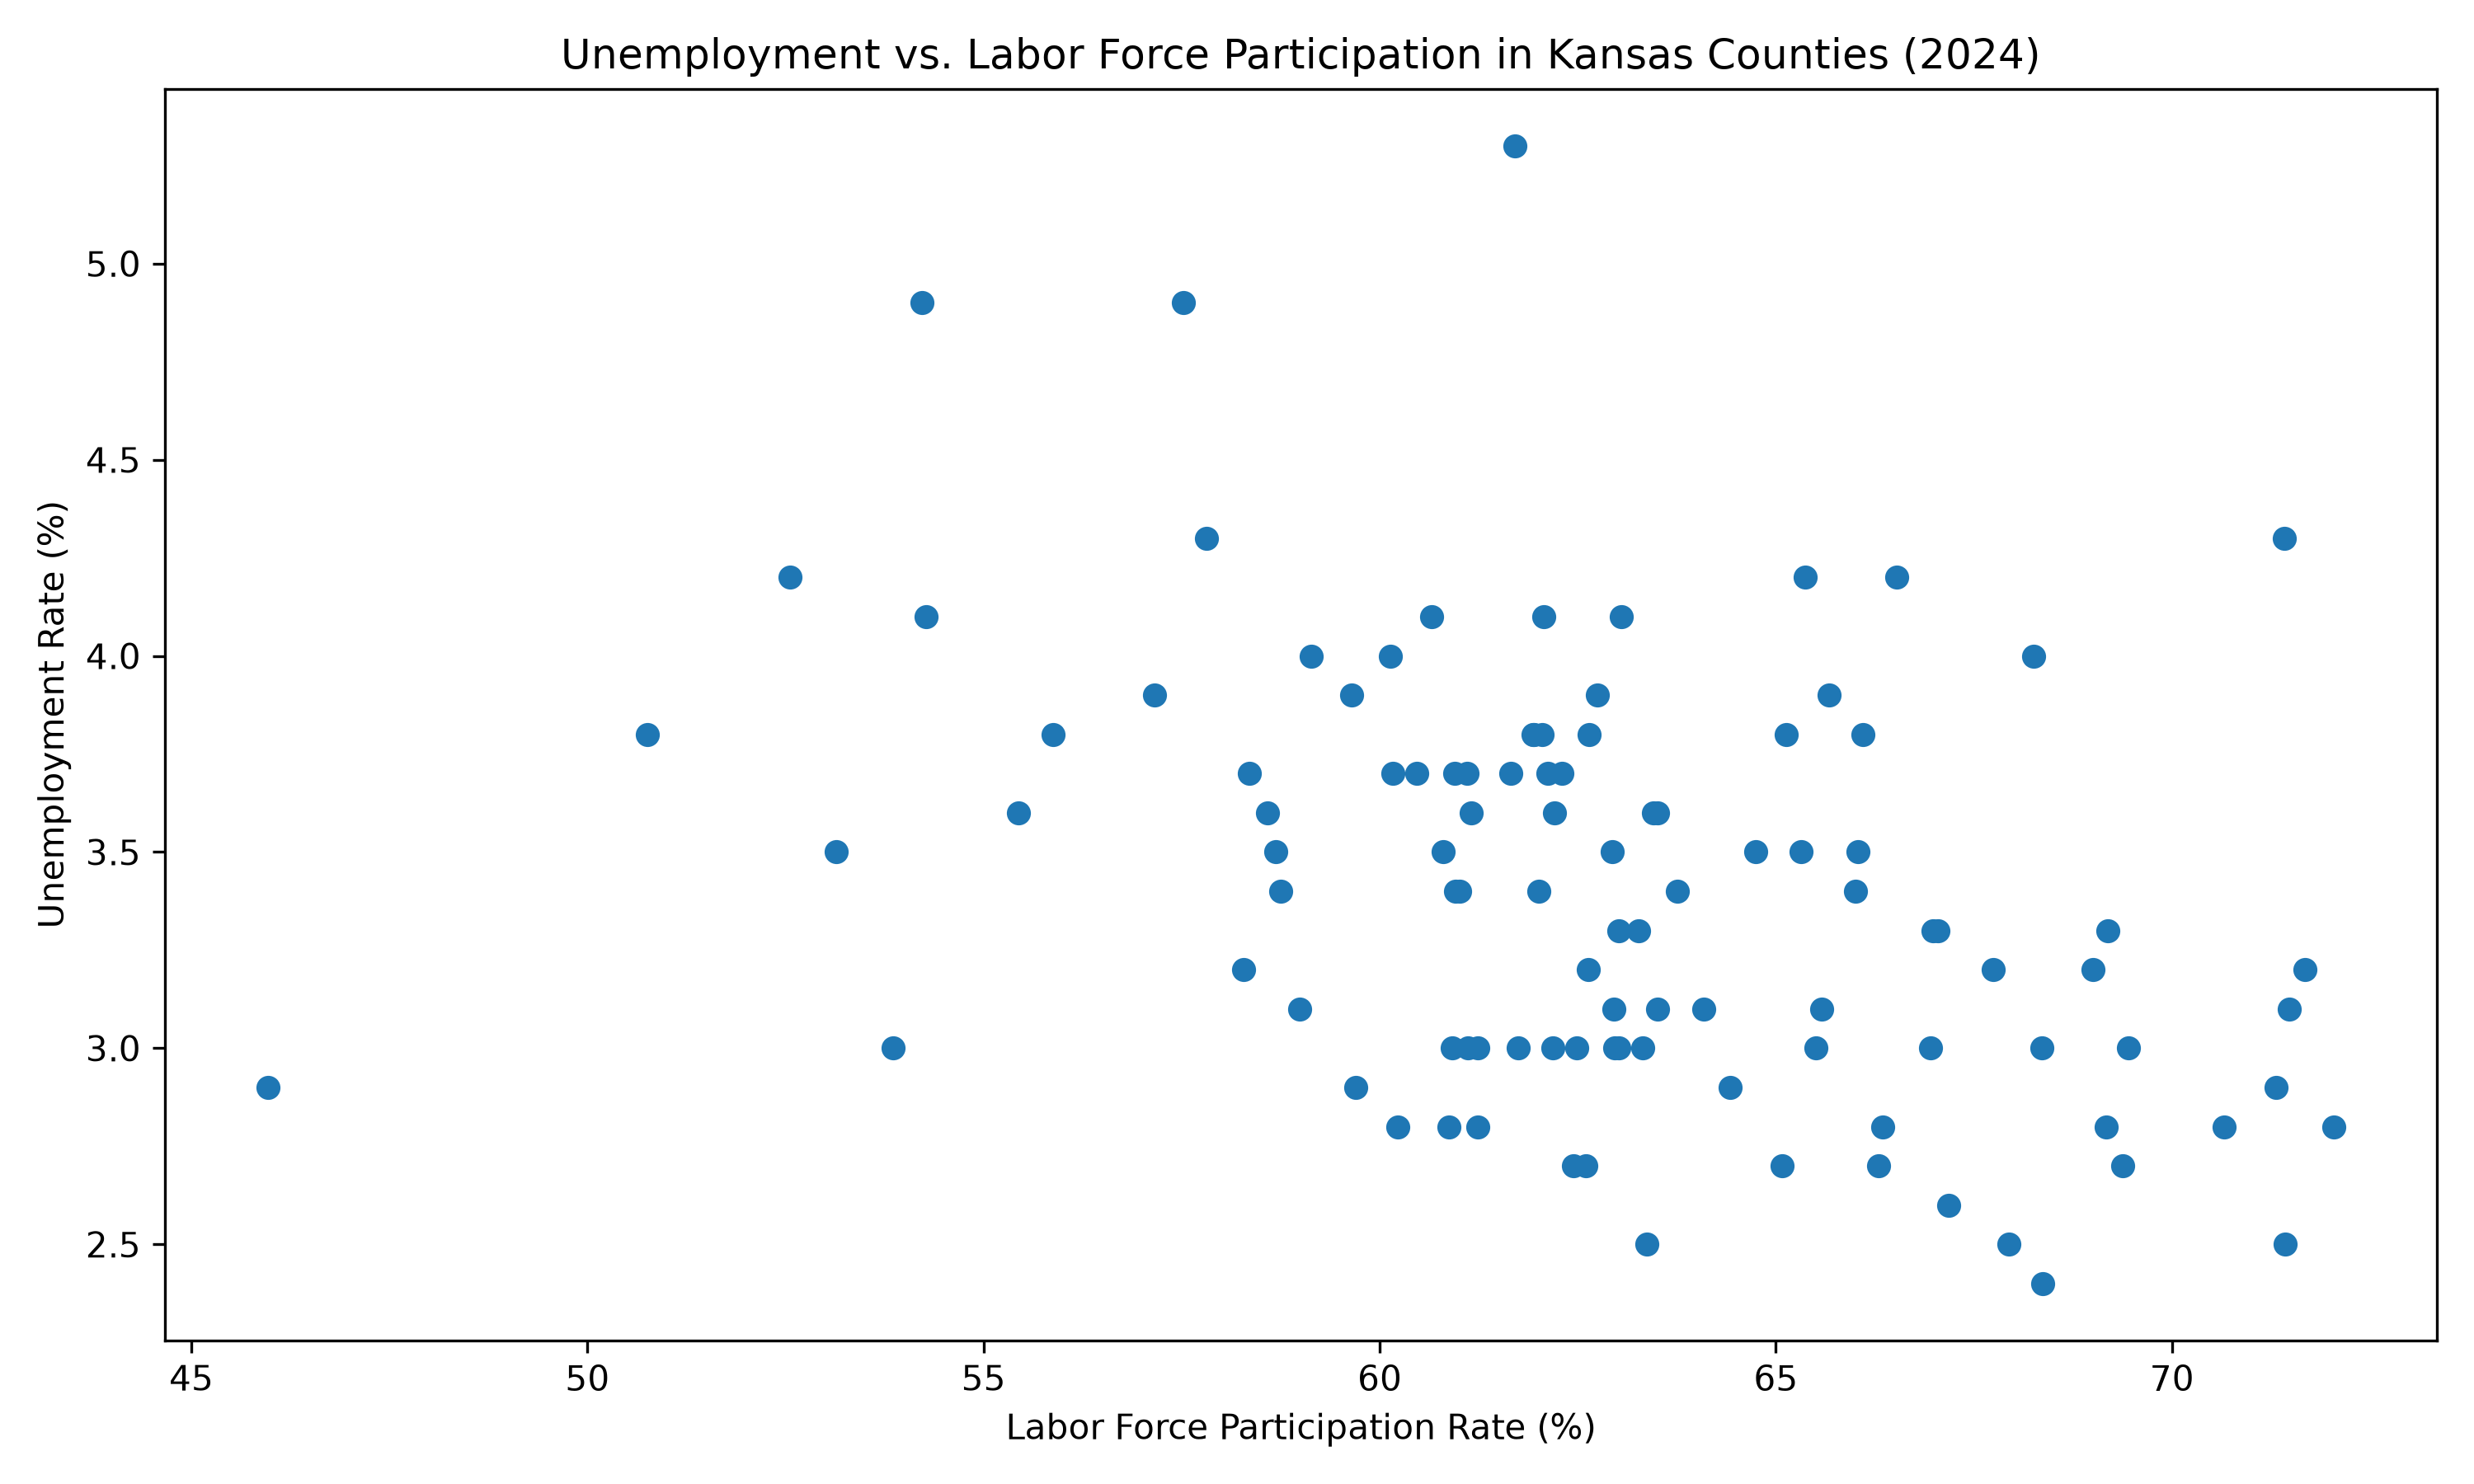

In [10]:
# Display unemployment vs. labor-force participation chart
display(
    Image(
        filename="../outputs/charts/unemployment_vs_labor_force.png"
    )
)

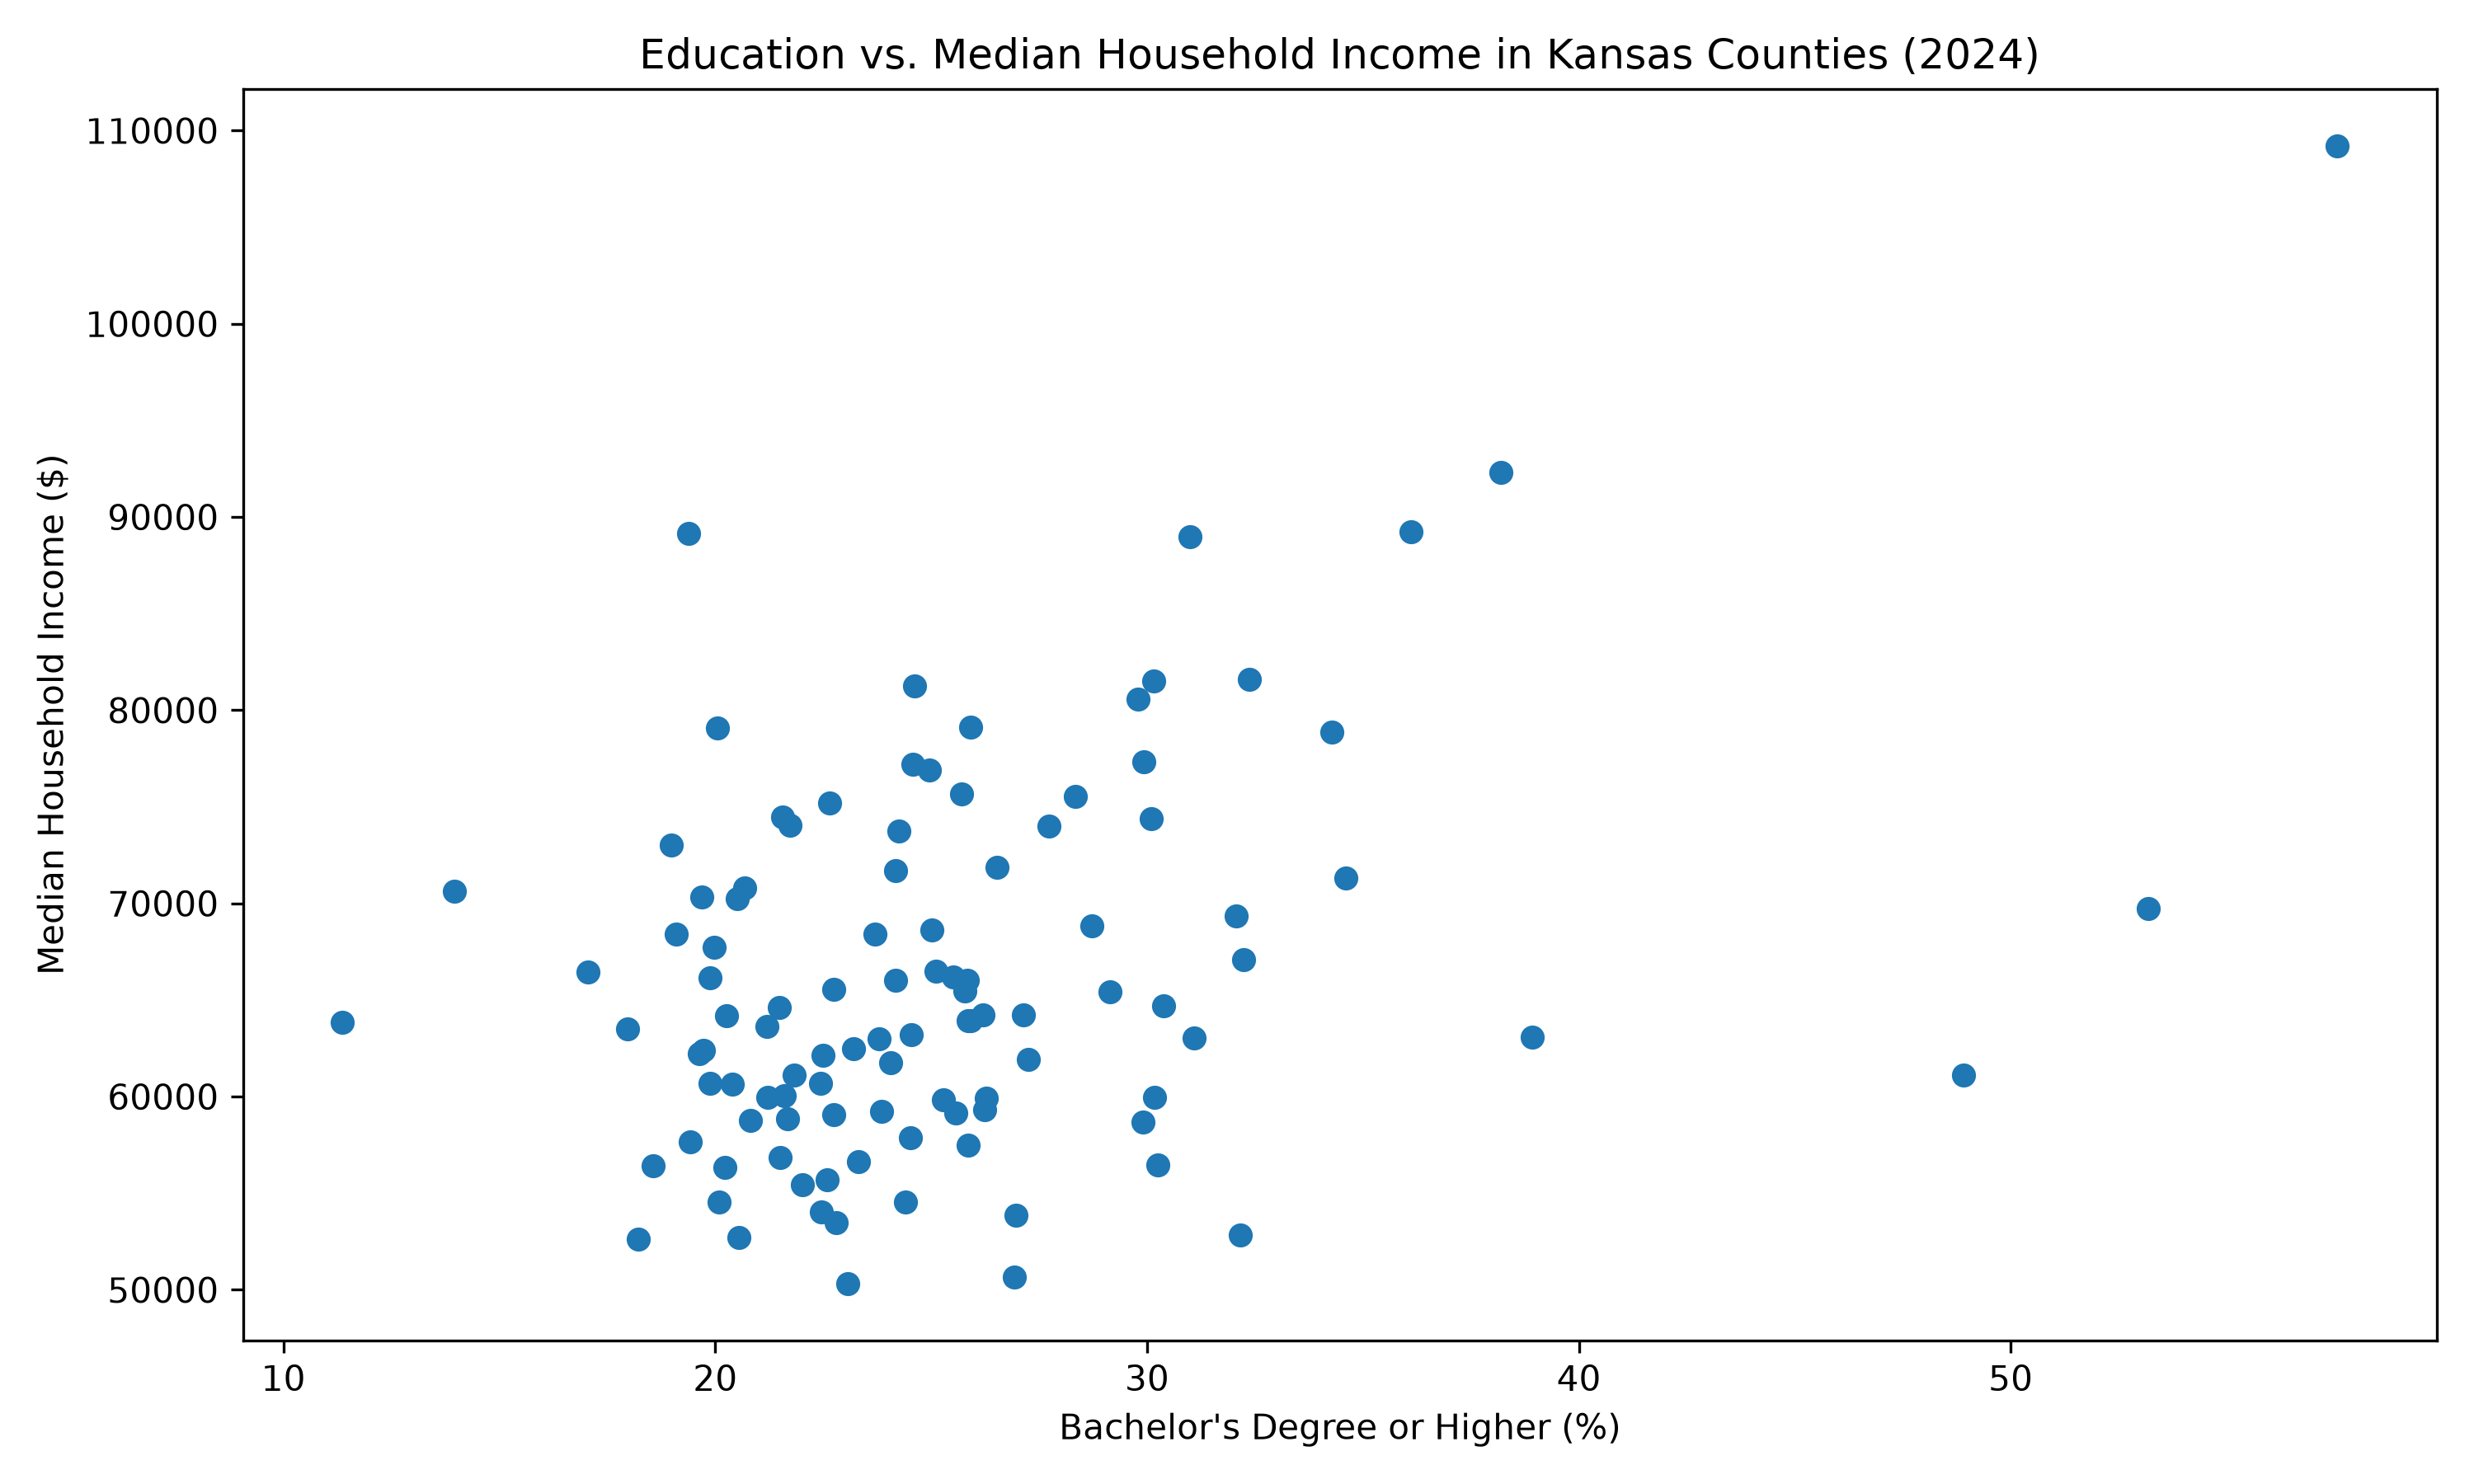

In [11]:
# Display educational attainment vs. household income chart
display(
    Image(
        filename="../outputs/charts/education_vs_income.png"
    )
)

### Educational Attainment and Household Income

The visualization shows a positive relationship between bachelor's-or-higher educational attainment and median household income across Kansas counties.

The correlation analysis found a correlation of **+0.40**, indicating that counties with higher educational attainment tended to have higher median household incomes.

For example, Johnson County had the highest bachelor's-or-higher rate among the counties identified in the ranking analysis at **57.56%**, along with a median household income of **$109,208**.

However, educational attainment was not statistically significant as an independent predictor of unemployment in the multiple regression model (**p = 0.848**). This demonstrates an important distinction: education may be associated with household income while not showing a statistically significant independent association with unemployment in this particular regression specification.

These findings represent county-level associations and do not establish causal relationships.

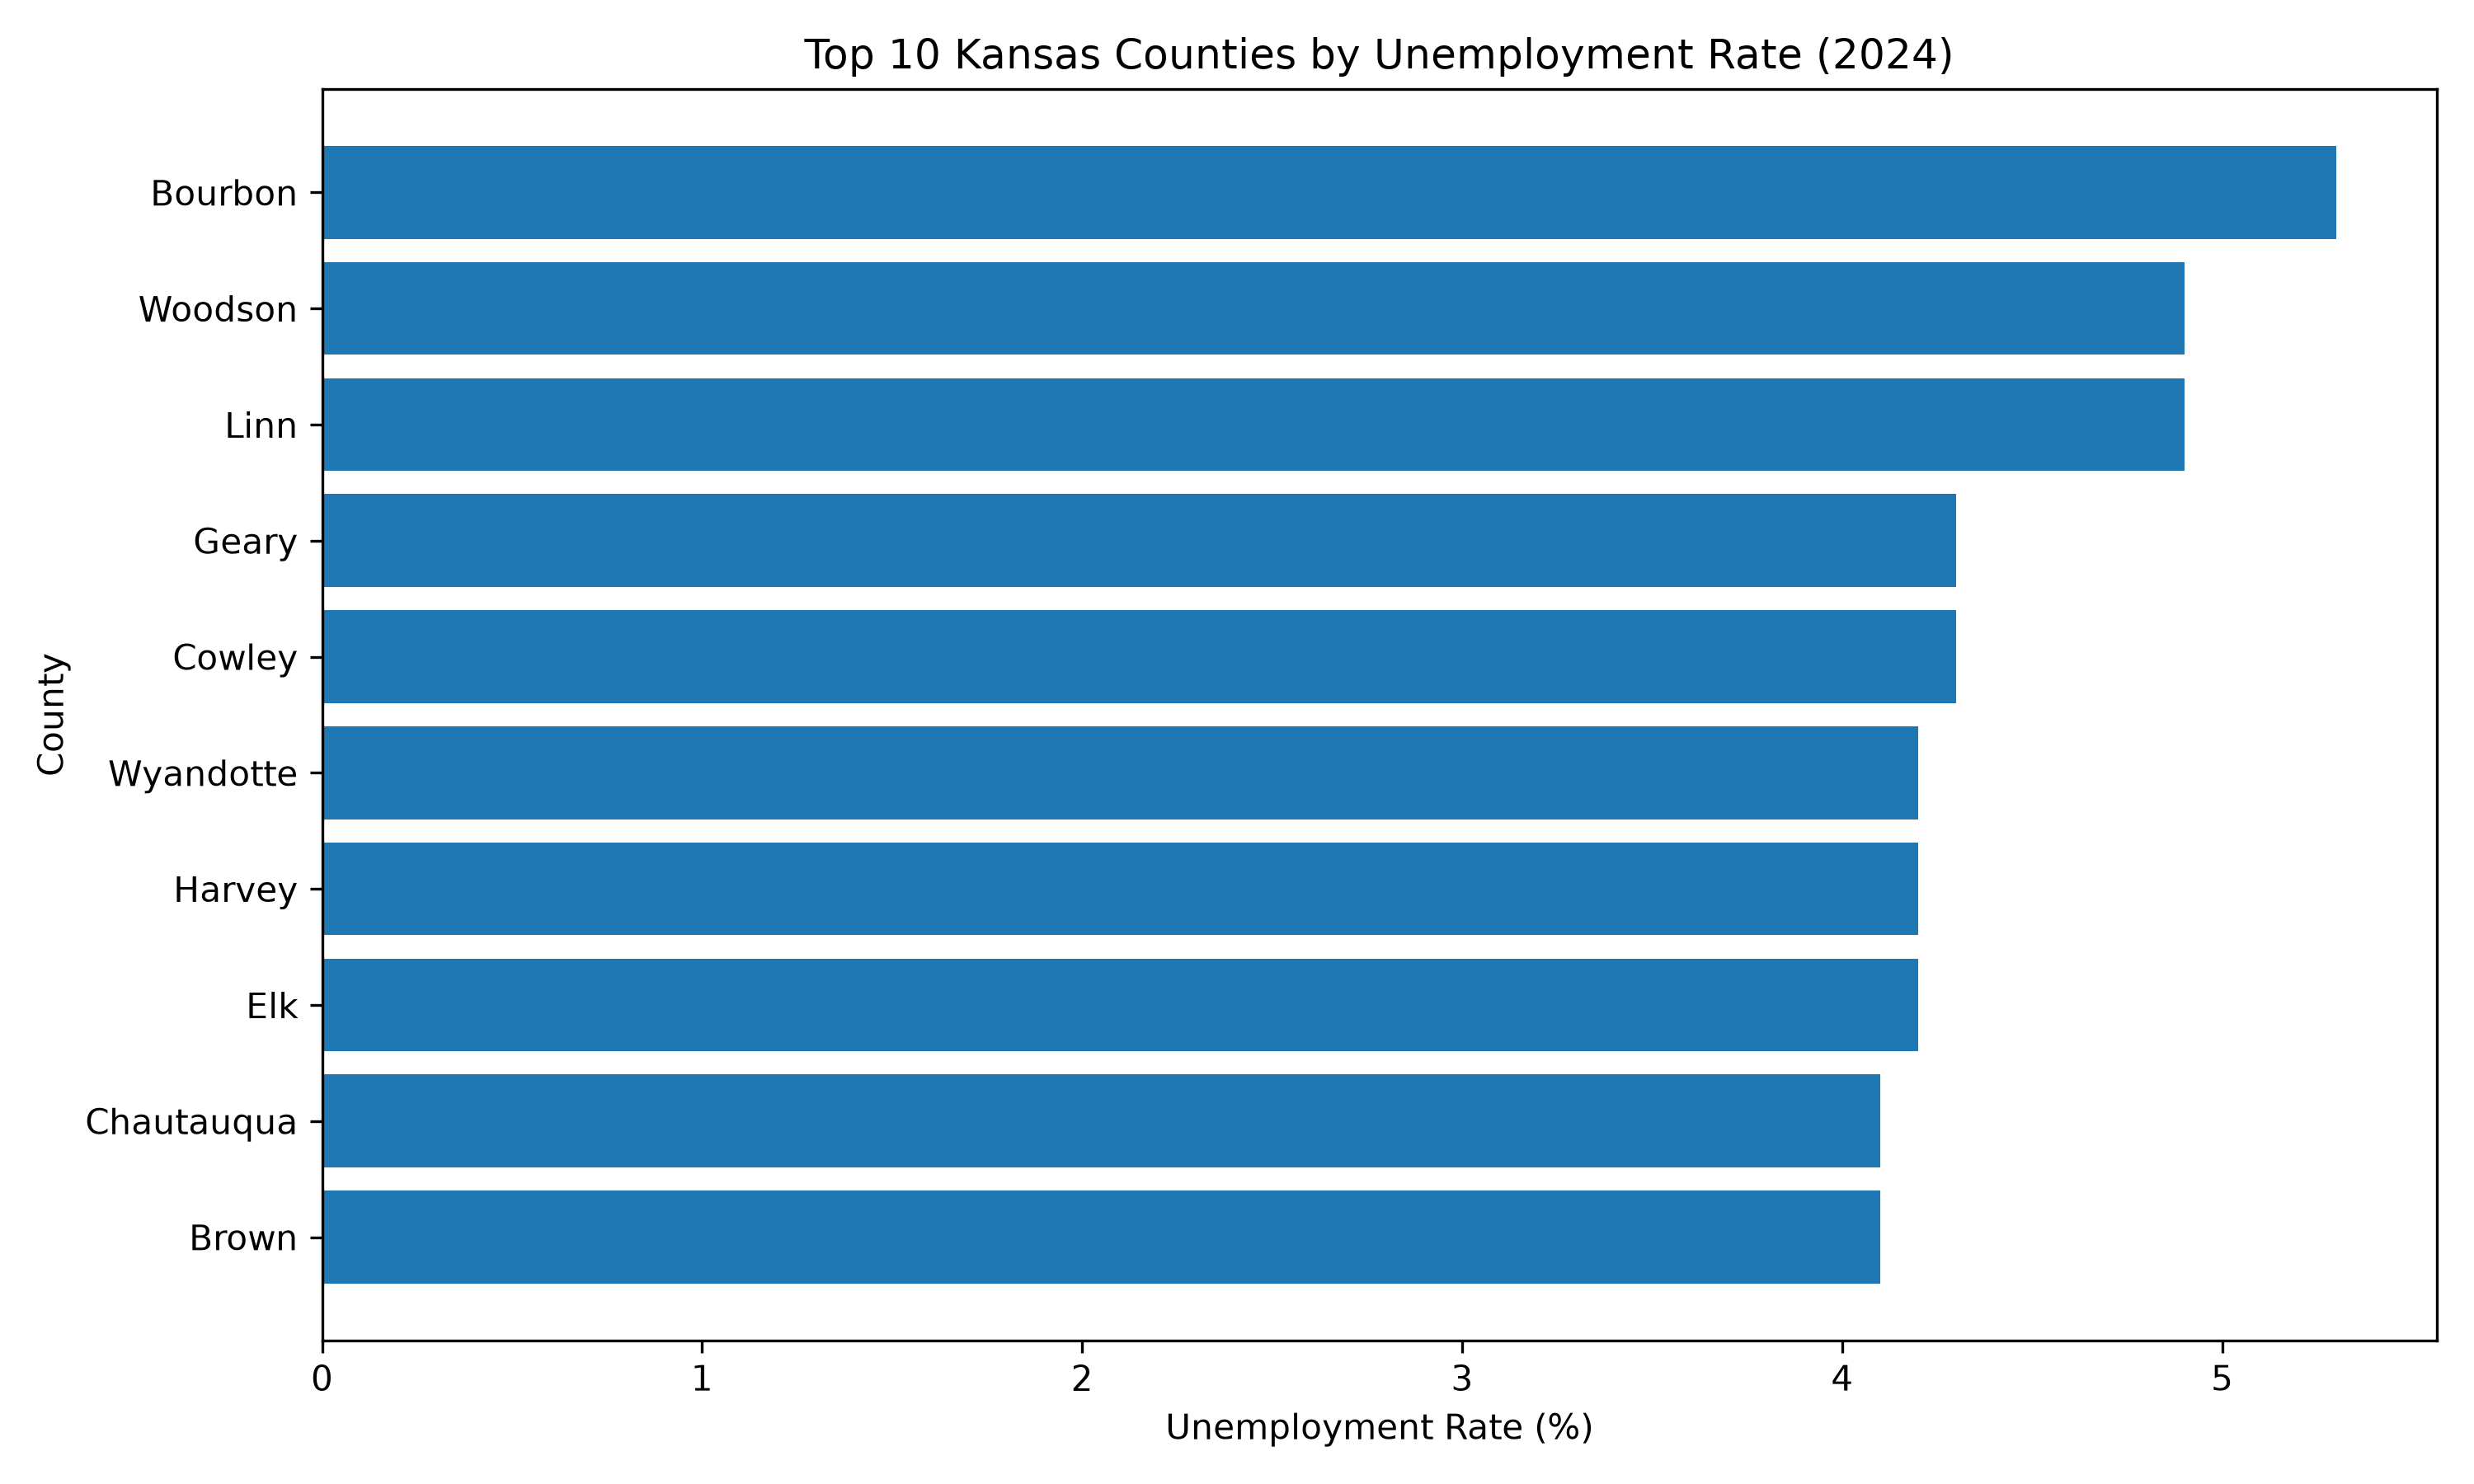

In [12]:
# Display the Top 10 Kansas counties by unemployment rate
display(
    Image(
        filename="../outputs/charts/top_10_unemployment.png"
    )
)

### Counties with the Highest Unemployment Rates

The county ranking shows that unemployment conditions varied considerably across Kansas in the 2024 BLS LAUS data.

**Bourbon County** had the highest unemployment rate at **5.3%**, followed by **Woodson County** and **Linn County**, both at **4.9%**.

The average unemployment rate across all 105 counties was approximately **3.4%**, meaning the counties at the top of the ranking were notably above the county average.

Several counties with relatively high unemployment also appeared in the earlier SQL analysis of counties with both above-average unemployment and above-average poverty. This demonstrates the value of examining multiple economic indicators rather than relying on unemployment alone.

These county rankings are descriptive and identify areas that may warrant further investigation; they do not by themselves explain why unemployment differs across counties.

## SQL Analysis

The cleaned county-level dataset was loaded into a SQLite database to demonstrate SQL-based analysis.

The SQL analysis focused on four business and policy-oriented questions:

1. Which Kansas counties had the highest unemployment rates?
2. Which counties had both above-average unemployment and above-average poverty?
3. Which counties had the lowest labor-force participation rates?
4. Which counties had the highest bachelor's-or-higher educational attainment rates, and what were their median household incomes?

SQL complements the Python analysis by demonstrating how structured queries can be used to filter, rank, and compare county-level economic indicators.

In [13]:
import sqlite3

# Connect to the project SQLite database
connection = sqlite3.connect(
    "../data/processed/kansas_economic_workforce.db"
)

print("Database connected successfully.")

Database connected successfully.


In [14]:
# Show all tables available in the SQLite database

tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
    """,
    connection
)

tables

,name
0,kansas_county_economic_data


In [15]:
# SQL query: Counties with above-average unemployment
# and above-average poverty

query = """
SELECT
    county_name,
    unemployment_rate,
    poverty_rate
FROM kansas_county_economic_data
WHERE unemployment_rate > (
    SELECT AVG(unemployment_rate)
    FROM kansas_county_economic_data
)
AND poverty_rate > (
    SELECT AVG(poverty_rate)
    FROM kansas_county_economic_data
)
ORDER BY unemployment_rate DESC, poverty_rate DESC;
"""

sql_high_unemployment_poverty = pd.read_sql_query(
    query,
    connection
)

sql_high_unemployment_poverty

,county_name,unemployment_rate,poverty_rate
0,"Bourbon County, Kansas",5.3,13.64
1,"Woodson County, Kansas",4.9,12.36
2,"Geary County, Kansas",4.3,18.01
3,"Cowley County, Kansas",4.3,14.26
4,"Wyandotte County, Kansas",4.2,15.76
5,"Wilson County, Kansas",4.1,15.48
6,"Chautauqua County, Kansas",4.1,14.92
7,"Brown County, Kansas",4.1,13.76
8,"Lincoln County, Kansas",4.1,11.34
9,"Russell County, Kansas",4.0,14.69


### SQL Findings: Unemployment and Poverty

The SQL analysis identified Kansas counties with both above-average unemployment and above-average poverty.

Examples included:

- Bourbon County
- Woodson County
- Geary County
- Cowley County
- Wyandotte County
- Wilson County
- Chautauqua County
- Brown County

This combined screening is more informative than ranking unemployment alone because it identifies counties experiencing challenges across multiple economic indicators.

The SQL approach also demonstrates how subqueries can be used to compare each county with statewide county-level averages and isolate areas that may warrant additional investigation.

In [16]:
# SQL query: Counties with the lowest labor-force participation rates

query = """
SELECT
    county_name,
    labor_force_participation_rate,
    unemployment_rate,
    poverty_rate
FROM kansas_county_economic_data
ORDER BY labor_force_participation_rate ASC, county_name ASC
LIMIT 10;
"""

sql_lowest_participation = pd.read_sql_query(
    query,
    connection
)

sql_lowest_participation

,county_name,labor_force_participation_rate,unemployment_rate,poverty_rate
0,"Norton County, Kansas",45.97,2.9,7.20
1,"Ellsworth County, Kansas",50.76,3.8,10.37
2,"Elk County, Kansas",52.56,4.2,10.37
3,"Morton County, Kansas",53.14,3.5,14.77
4,"Pawnee County, Kansas",53.86,3.0,11.52
5,"Woodson County, Kansas",54.22,4.9,12.36
6,"Chautauqua County, Kansas",54.27,4.1,14.92
7,"Harper County, Kansas",55.44,3.6,17.30
8,"Chase County, Kansas",55.88,3.8,8.35
9,"Montgomery County, Kansas",57.16,3.9,15.92


### SQL Findings: Labor-Force Participation

The SQL results show that some Kansas counties had relatively low labor-force participation even when their unemployment rates were not especially high.

For example:

- **Norton County** had the lowest labor-force participation rate in the analysis at **45.97%**, while its unemployment rate was **2.9%**.
- **Ellsworth County** had labor-force participation of **50.76%** and unemployment of **3.8%**.
- **Woodson County** combined relatively low labor-force participation (**54.22%**) with relatively high unemployment (**4.9%**).

This illustrates why unemployment should not be interpreted by itself. A county can have a low unemployment rate while also having a relatively small share of its population participating in the labor force.

Examining both measures provides a more complete view of local workforce conditions.

In [17]:
# SQL query: Counties with the highest educational attainment

query = """
SELECT
    county_name,
    bachelors_or_higher_rate,
    median_household_income
FROM kansas_county_economic_data
ORDER BY bachelors_or_higher_rate DESC,
         median_household_income DESC
LIMIT 10;
"""

sql_education_income = pd.read_sql_query(
    query,
    connection
)

sql_education_income

,county_name,bachelors_or_higher_rate,median_household_income
0,"Johnson County, Kansas",57.56,109208
1,"Douglas County, Kansas",53.19,69746
2,"Riley County, Kansas",48.91,61098
3,"Ellis County, Kansas",38.91,63084
4,"Pottawatomie County, Kansas",38.19,92325
5,"Leavenworth County, Kansas",36.12,89218
6,"Thomas County, Kansas",34.61,71325
7,"McPherson County, Kansas",34.27,78851
8,"Butler County, Kansas",32.37,81610
9,"Shawnee County, Kansas",32.23,67104


### SQL Findings: Educational Attainment and Income

The SQL ranking shows that counties with the highest educational attainment rates varied considerably in household income.

- **Johnson County** had the highest bachelor's-or-higher attainment rate at **57.56%** and a median household income of **$109,208**.
- **Douglas County** had an attainment rate of **53.19%** and median household income of **$69,746**.
- **Riley County** had an attainment rate of **48.91%** and median household income of **$61,098**.
- **Pottawatomie County** had an attainment rate of **38.19%** and median household income of **$92,325**.

The ranking is based primarily on educational attainment rather than household income. Therefore, these results should not be interpreted as a ranking of the highest-income Kansas counties.

Combined with the correlation analysis, the results show a positive county-level association between educational attainment and median household income, while also showing that counties with similar educational attainment levels can have different income levels.

## Key Findings

The analysis identified several important patterns in economic and workforce conditions across Kansas counties.

1. **Unemployment varied considerably across counties.**  
   The average county unemployment rate was approximately **3.4%**, while Bourbon County had the highest rate at **5.3%**. Woodson and Linn counties followed at **4.9%**.

2. **Labor-force participation was negatively associated with unemployment.**  
   The correlation between labor-force participation and unemployment was **-0.35**. In the multiple regression model, labor-force participation was the only predictor statistically significant at the 5% level (**coefficient = -0.0378, p = 0.002**).

3. **Low unemployment did not always indicate strong labor-force participation.**  
   Norton County had an unemployment rate of only **2.9%**, but its labor-force participation rate was **45.97%**, the lowest among the counties analyzed.

4. **Higher household income was associated with lower poverty.**  
   Poverty and median household income had a correlation of **-0.49**, one of the stronger relationships observed in the analysis.

5. **Educational attainment was positively associated with household income.**  
   Bachelor's-or-higher attainment and median household income had a correlation of **+0.40**. Johnson County had the highest educational attainment rate in the ranking at **57.56%** and a median household income of **$109,208**.

6. **The regression model explained only part of the differences in unemployment.**  
   The model had an **R² of 0.175**, indicating that the four included predictors explained approximately **17.5%** of the variation in county unemployment rates. Other economic, demographic, geographic, and industry-related factors may account for additional variation.

Overall, the findings demonstrate the importance of examining multiple indicators when evaluating local workforce conditions rather than relying on unemployment alone.

## Data Sources

### U.S. Census Bureau — American Community Survey (ACS) 5-Year Estimates, 2024

The Census ACS data provides county-level demographic and socioeconomic indicators used in this project, including:

- Total population
- Median household income
- Civilian labor force
- Population age 16 and older
- Unemployed population
- Poverty status
- Population age 25 and older
- Bachelor's, master's, professional, and doctorate degree attainment

These variables were retrieved through the Census API for all 105 Kansas counties.

### Bureau of Labor Statistics — Local Area Unemployment Statistics (LAUS), 2024 Annual Averages

The BLS LAUS county dataset provides:

- Labor force
- Employment
- Unemployment
- Unemployment rate

The national county file was filtered to Kansas using State FIPS Code 20.

### Geographic Matching

Census and BLS data were merged using:

- State FIPS code
- County FIPS code

This produced a final dataset containing all 105 Kansas counties.



## Data Preparation

The Census ACS and BLS LAUS datasets required several preparation steps before analysis.

### Census Data Preparation

The Census API data was processed to:

- Rename Census variable codes into understandable column names.
- Convert numeric variables from text to numeric data types.
- Calculate labor force participation rate.
- Calculate unemployment rate.
- Calculate poverty rate.
- Combine bachelor's, master's, professional, and doctorate degree counts.
- Calculate the percentage of adults age 25 and older with a bachelor's degree or higher.

### BLS Data Preparation

The BLS LAUS county file was processed to:

- Correct the Excel header structure.
- Filter the national dataset to Kansas counties.
- Select labor force, employment, unemployment, and unemployment rate measures.
- Standardize State and County FIPS codes.

### Data Integration and Validation

The Census and BLS datasets were merged using State and County FIPS codes.

The final dataset contained:

- **105 Kansas counties**
- **26 variables**
- **0 duplicate counties**
- **0 missing values in the analyzed variables**

FIPS codes were used for the merge instead of county names because the Census and BLS datasets use different county-name formats.



In [18]:

import pandas as pd

# Load the final merged Kansas dataset
file_path = "../data/processed/kansas_economic_workforce_2024.csv"
df = pd.read_csv(file_path)

# Display the first five rows
df.head()



,county_name_census,population,median_household_income,civilian_labor_force,population_16_plus,unemployed_census,poverty_universe,below_poverty,population_25_plus,bachelors_degree,...,unemployment_rate_census,poverty_rate,bachelors_or_higher,bachelors_or_higher_rate,county_name_bls,year,labor_force,employed,unemployed_bls,unemployment_rate_bls
0,"Allen County, Kansas",12483,60689,6269,9991,496,12018,1192,8477,1231,...,7.91,9.92,1902,22.44,"Allen County, KS",2024.0,6051.0,5813.0,238.0,3.9
1,"Anderson County, Kansas",7834,70614,3710,5983,152,7724,853,5214,426,...,4.10,11.04,728,13.96,"Anderson County, KS",2024.0,3782.0,3655.0,127.0,3.4
2,"Atchison County, Kansas",16208,61112,8170,13043,375,14574,1891,9846,1322,...,4.59,12.98,2149,21.83,"Atchison County, KS",2024.0,8115.0,7808.0,307.0,3.8
3,"Barber County, Kansas",4069,61926,2248,3237,28,3966,467,2774,597,...,1.25,11.78,756,27.25,"Barber County, KS",2024.0,2077.0,2015.0,62.0,3.0
4,"Barton County, Kansas",25097,58851,12424,19743,483,24591,3787,17024,2660,...,3.89,15.40,3690,21.68,"Barton County, KS",2024.0,12369.0,11942.0,427.0,3.5


In [19]:
# Check the size of the final dataset
print("Dataset shape:", df.shape)

# Check for duplicate counties
print("Duplicate counties:", df["county_fips"].duplicated().sum())

# Check missing values in the main analysis variables
analysis_columns = [
    "unemployment_rate_bls",
    "poverty_rate",
    "median_household_income",
    "bachelors_or_higher_rate",
    "labor_force_participation_rate"
]

print("\nMissing values:")
print(df[analysis_columns].isnull().sum())

Dataset shape: (105, 26)
Duplicate counties: 0

Missing values:
unemployment_rate_bls             0
poverty_rate                      0
median_household_income           0
bachelors_or_higher_rate          0
labor_force_participation_rate    0
dtype: int64


## Exploratory Data Analysis

The next step examines differences in unemployment across Kansas counties. Ranking counties by unemployment rate helps identify areas experiencing relatively higher and lower unemployment in the 2024 BLS LAUS data.


In [20]:
# Select county name and unemployment rate
unemployment_analysis = df[
    ["county_name_census", "unemployment_rate_bls"]
].copy()

# Rename columns for easier reading
unemployment_analysis.columns = [
    "County",
    "Unemployment Rate"
]

# Display the 10 counties with the highest unemployment rates
top_10_unemployment = unemployment_analysis.sort_values(
    by="Unemployment Rate",
    ascending=False
).head(10)

top_10_unemployment

,County,Unemployment Rate
5,"Bourbon County, Kansas",5.3
103,"Woodson County, Kansas",4.9
53,"Linn County, Kansas",4.9
17,"Cowley County, Kansas",4.3
30,"Geary County, Kansas",4.3
104,"Wyandotte County, Kansas",4.2
39,"Harvey County, Kansas",4.2
24,"Elk County, Kansas",4.2
102,"Wilson County, Kansas",4.1
52,"Lincoln County, Kansas",4.1


### Unemployment Findings

The county-level analysis shows meaningful variation in unemployment across Kansas.

- **Bourbon County** had the highest unemployment rate in the dataset at **5.3%**.
- **Woodson County** and **Linn County** followed at **4.9%**.
- Other counties with relatively high unemployment included Cowley, Geary, Wyandotte, Harvey, Elk, Wilson, and Lincoln counties.
- The average unemployment rate across the 105 Kansas counties was approximately **3.4%**.

These results show that statewide or average measures can hide important differences between individual counties. Examining county-level data makes it possible to identify areas experiencing relatively greater labor-market challenges.

## Correlation Analysis

Correlation analysis is used to examine the direction and strength of relationships among the main economic and workforce indicators.

The analysis includes:

- Unemployment rate
- Poverty rate
- Median household income
- Bachelor's-or-higher educational attainment rate
- Labor-force participation rate

Correlation values range from **-1 to +1**. A positive value indicates that two variables tend to move in the same direction, while a negative value indicates that they tend to move in opposite directions. Correlation describes association and does not establish causation.

In [21]:
# Select variables for correlation analysis
correlation_columns = [
    "unemployment_rate_bls",
    "poverty_rate",
    "median_household_income",
    "bachelors_or_higher_rate",
    "labor_force_participation_rate"
]

# Calculate the correlation matrix
correlation_matrix = df[correlation_columns].corr().round(2)

# Display the correlation matrix
correlation_matrix

,unemployment_rate_bls,poverty_rate,median_household_income,bachelors_or_higher_rate,labor_force_participation_rate
unemployment_rate_bls,1.00,0.23,-0.28,-0.15,-0.35
poverty_rate,0.23,1.00,-0.49,-0.07,-0.05
median_household_income,-0.28,-0.49,1.00,0.40,0.40
bachelors_or_higher_rate,-0.15,-0.07,0.40,1.00,0.41
labor_force_participation_rate,-0.35,-0.05,0.40,0.41,1.00


In [22]:
correlation_columns = [
    "unemployment_rate_bls",
    "poverty_rate",
    "median_household_income",
    "bachelors_or_higher_rate",
    "labor_force_participation_rate"
]

correlation_matrix = df[correlation_columns].corr().round(2)

correlation_matrix


,unemployment_rate_bls,poverty_rate,median_household_income,bachelors_or_higher_rate,labor_force_participation_rate
unemployment_rate_bls,1.00,0.23,-0.28,-0.15,-0.35
poverty_rate,0.23,1.00,-0.49,-0.07,-0.05
median_household_income,-0.28,-0.49,1.00,0.40,0.40
bachelors_or_higher_rate,-0.15,-0.07,0.40,1.00,0.41
labor_force_participation_rate,-0.35,-0.05,0.40,0.41,1.00


## Multiple Linear Regression

A multiple linear regression model was used to examine how several county-level characteristics are associated with unemployment when considered together.

### Dependent Variable

- BLS unemployment rate

### Independent Variables

- Poverty rate
- Median household income
- Bachelor's-or-higher educational attainment rate
- Labor-force participation rate

The regression estimates the association between each predictor and unemployment while holding the other variables in the model constant.


In [23]:
import statsmodels.api as sm

# Define the dependent variable
y = df["unemployment_rate_bls"]

# Define the independent variables
X = df[
    [
        "poverty_rate",
        "median_household_income",
        "bachelors_or_higher_rate",
        "labor_force_participation_rate"
    ]
]

# Add the regression intercept
X = sm.add_constant(X)

# Fit the multiple linear regression model
model = sm.OLS(y, X).fit()

# Display the regression results
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     unemployment_rate_bls   R-squared:                       0.175
Model:                               OLS   Adj. R-squared:                  0.142
Method:                    Least Squares   F-statistic:                     5.291
Date:                   Tue, 29 Sep 2026   Prob (F-statistic):           0.000660
Time:                           00:57:36   Log-Likelihood:                -74.979
No. Observations:                    105   AIC:                             160.0
Df Residuals:                        100   BIC:                             173.2
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              5.6671      0.729      7.771      0.000       4.220       7.114
poverty_rate                       0.0275      0.016      1.738      0.085      -0.004       0.059
median_household_income        -3.608e-06   6.67e-06     -0.541      0.590   -1.68e-05    9.63e-06
bachelors_or_higher_rate           0.0016      0.008      0.192      0.848      -0.015       0.018
labor_force_participation_rate    -0.0378      0.012     -3.120      0.002      -0.062      -0.014
==============================================================================
Omnibus:                        8.535   Durbin-Watson:                   1.644
Prob(Omnibus):                  0.014   Jarque-Bera (JB):                8.355
Skew:                           0.587   Prob(JB):                       0.0153
Kurtosis:                       3.728   Cond. No.                     9.88e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.88e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Regression Findings

The multiple linear regression model was statistically significant overall (**F-test p = 0.000660**) and explained approximately **17.5% of the variation in county unemployment rates (R² = 0.175)**.

Among the four predictors:

- **Labor-force participation rate** was statistically significant (**coefficient = -0.0378, p = 0.002**). Holding the other variables constant, a 1 percentage-point increase in labor-force participation was associated with approximately a 0.038 percentage-point decrease in the unemployment rate.
- **Poverty rate** had a positive coefficient (**0.0275**) but was not statistically significant at the 5% level (**p = 0.085**).
- **Median household income** was not statistically significant (**p = 0.590**).
- **Bachelor's-or-higher educational attainment** was not statistically significant (**p = 0.848**).

The results suggest that labor-force participation had the clearest independent association with county unemployment among the variables included in this model. However, the relatively low R² indicates that much of the variation in county unemployment is associated with factors not included in this model.

These results describe statistical associations and should not be interpreted as evidence of causal relationships.


## Multicollinearity Diagnostic

Variance Inflation Factor (VIF) was used to check whether the independent variables in the regression model were highly correlated with one another.

High multicollinearity can make regression coefficients unstable and difficult to interpret. As a general diagnostic guideline, VIF values below 5 indicate that serious multicollinearity is not evident.


In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each regression variable
vif_data = pd.DataFrame()

vif_data["Variable"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Variable,VIF
0,const,1.000000
1,poverty_rate,1.381995
2,median_household_income,1.781832
3,bachelors_or_higher_rate,1.321090
4,labor_force_participation_rate,1.329461


### VIF Findings

The VIF results indicate that multicollinearity is not a major concern in the regression model.

- Poverty rate: **VIF = 1.38**
- Median household income: **VIF = 1.78**
- Bachelor's-or-higher rate: **VIF = 1.32**
- Labor-force participation rate: **VIF = 1.33**

All predictor VIF values are well below 5. This suggests that the independent variables are not excessively correlated with one another and can reasonably be included together in the regression model.

The regression output also reported a large condition number. Because median household income is measured in dollars while the other predictors are percentages, differences in variable scale can contribute to a large condition number. The VIF results provide additional evidence that severe predictor multicollinearity is not apparent.


## Visual Analysis

The following visualizations provide additional context for the relationships identified in the descriptive, correlation, and regression analyses.

The charts examine:

- Poverty and median household income
- Unemployment and labor-force participation
- Educational attainment and household income
- Counties with the highest unemployment rates


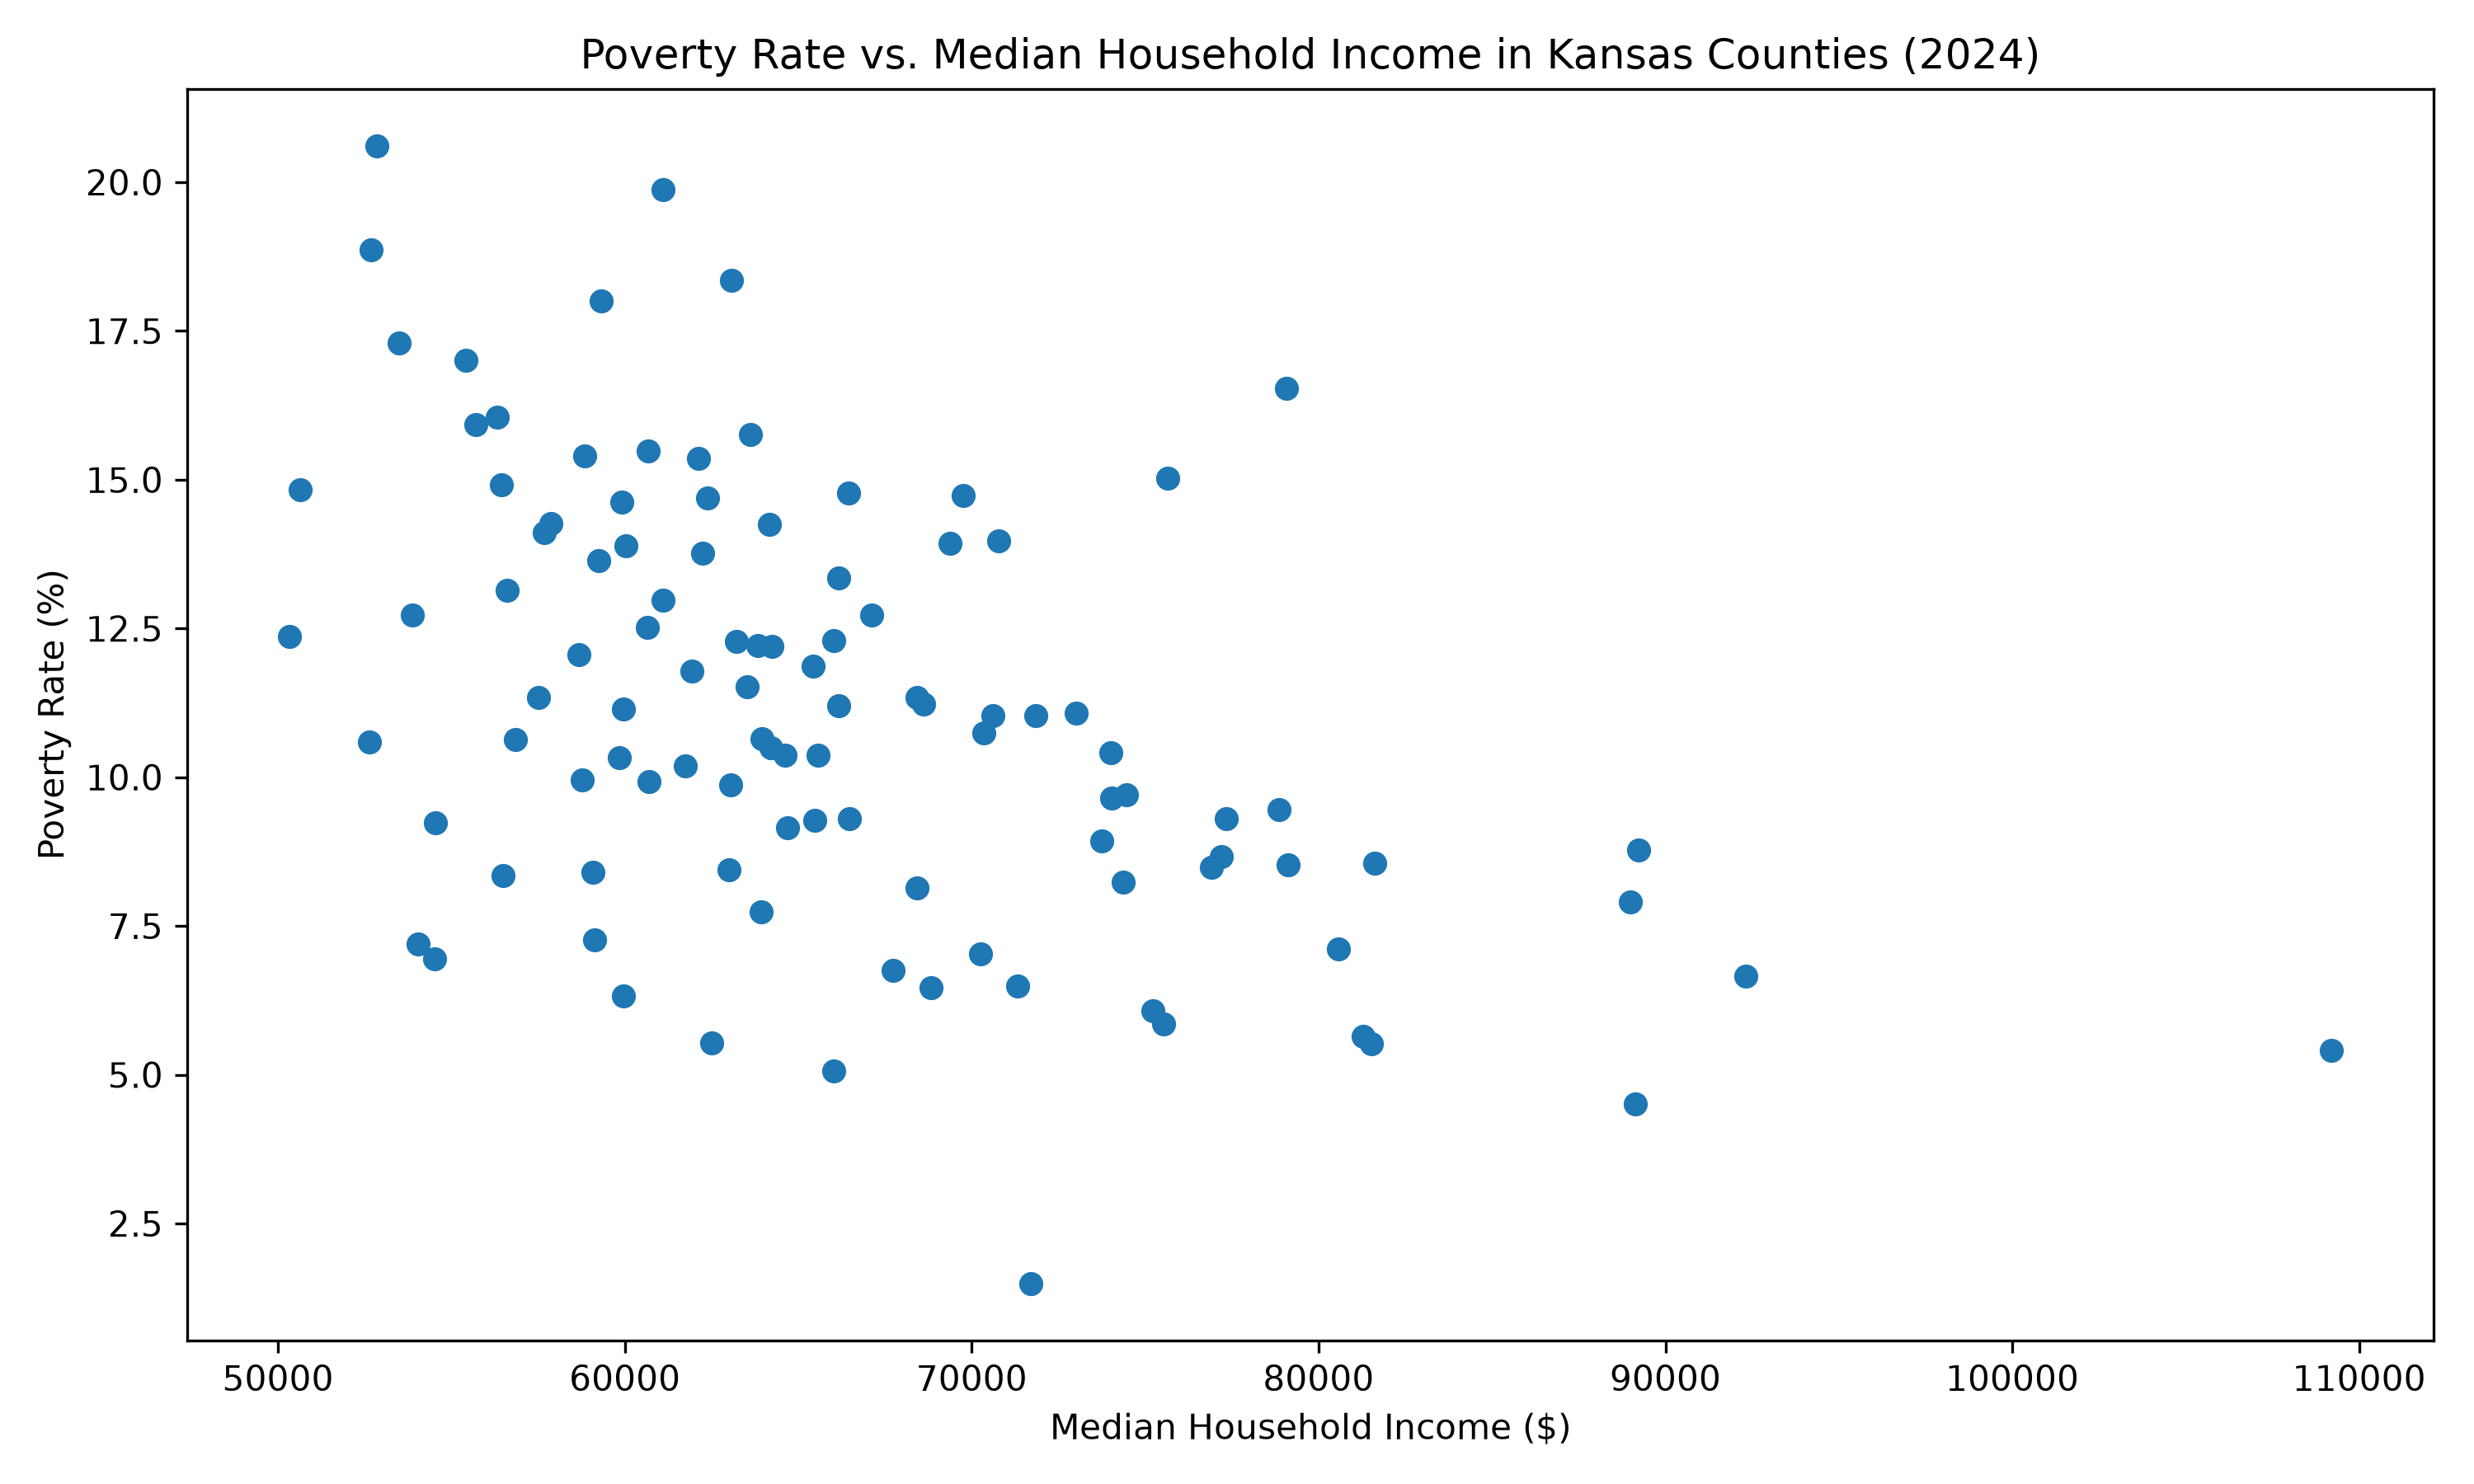

In [25]:
from IPython.display import Image, display

# Display poverty vs. median household income chart
display(
    Image(
        filename="../outputs/charts/poverty_vs_income.png"
    )
)

### Poverty and Household Income

The visualization shows a general negative relationship between poverty and median household income across Kansas counties.

This pattern is consistent with the correlation analysis, which found a correlation of **-0.49** between poverty rate and median household income. Counties with higher median household incomes generally tended to have lower poverty rates.

The relationship is not perfect, however, because counties with similar income levels can still have different poverty rates. This suggests that household income alone does not fully explain county-level differences in poverty.

The observed relationship represents an association and does not establish causation.

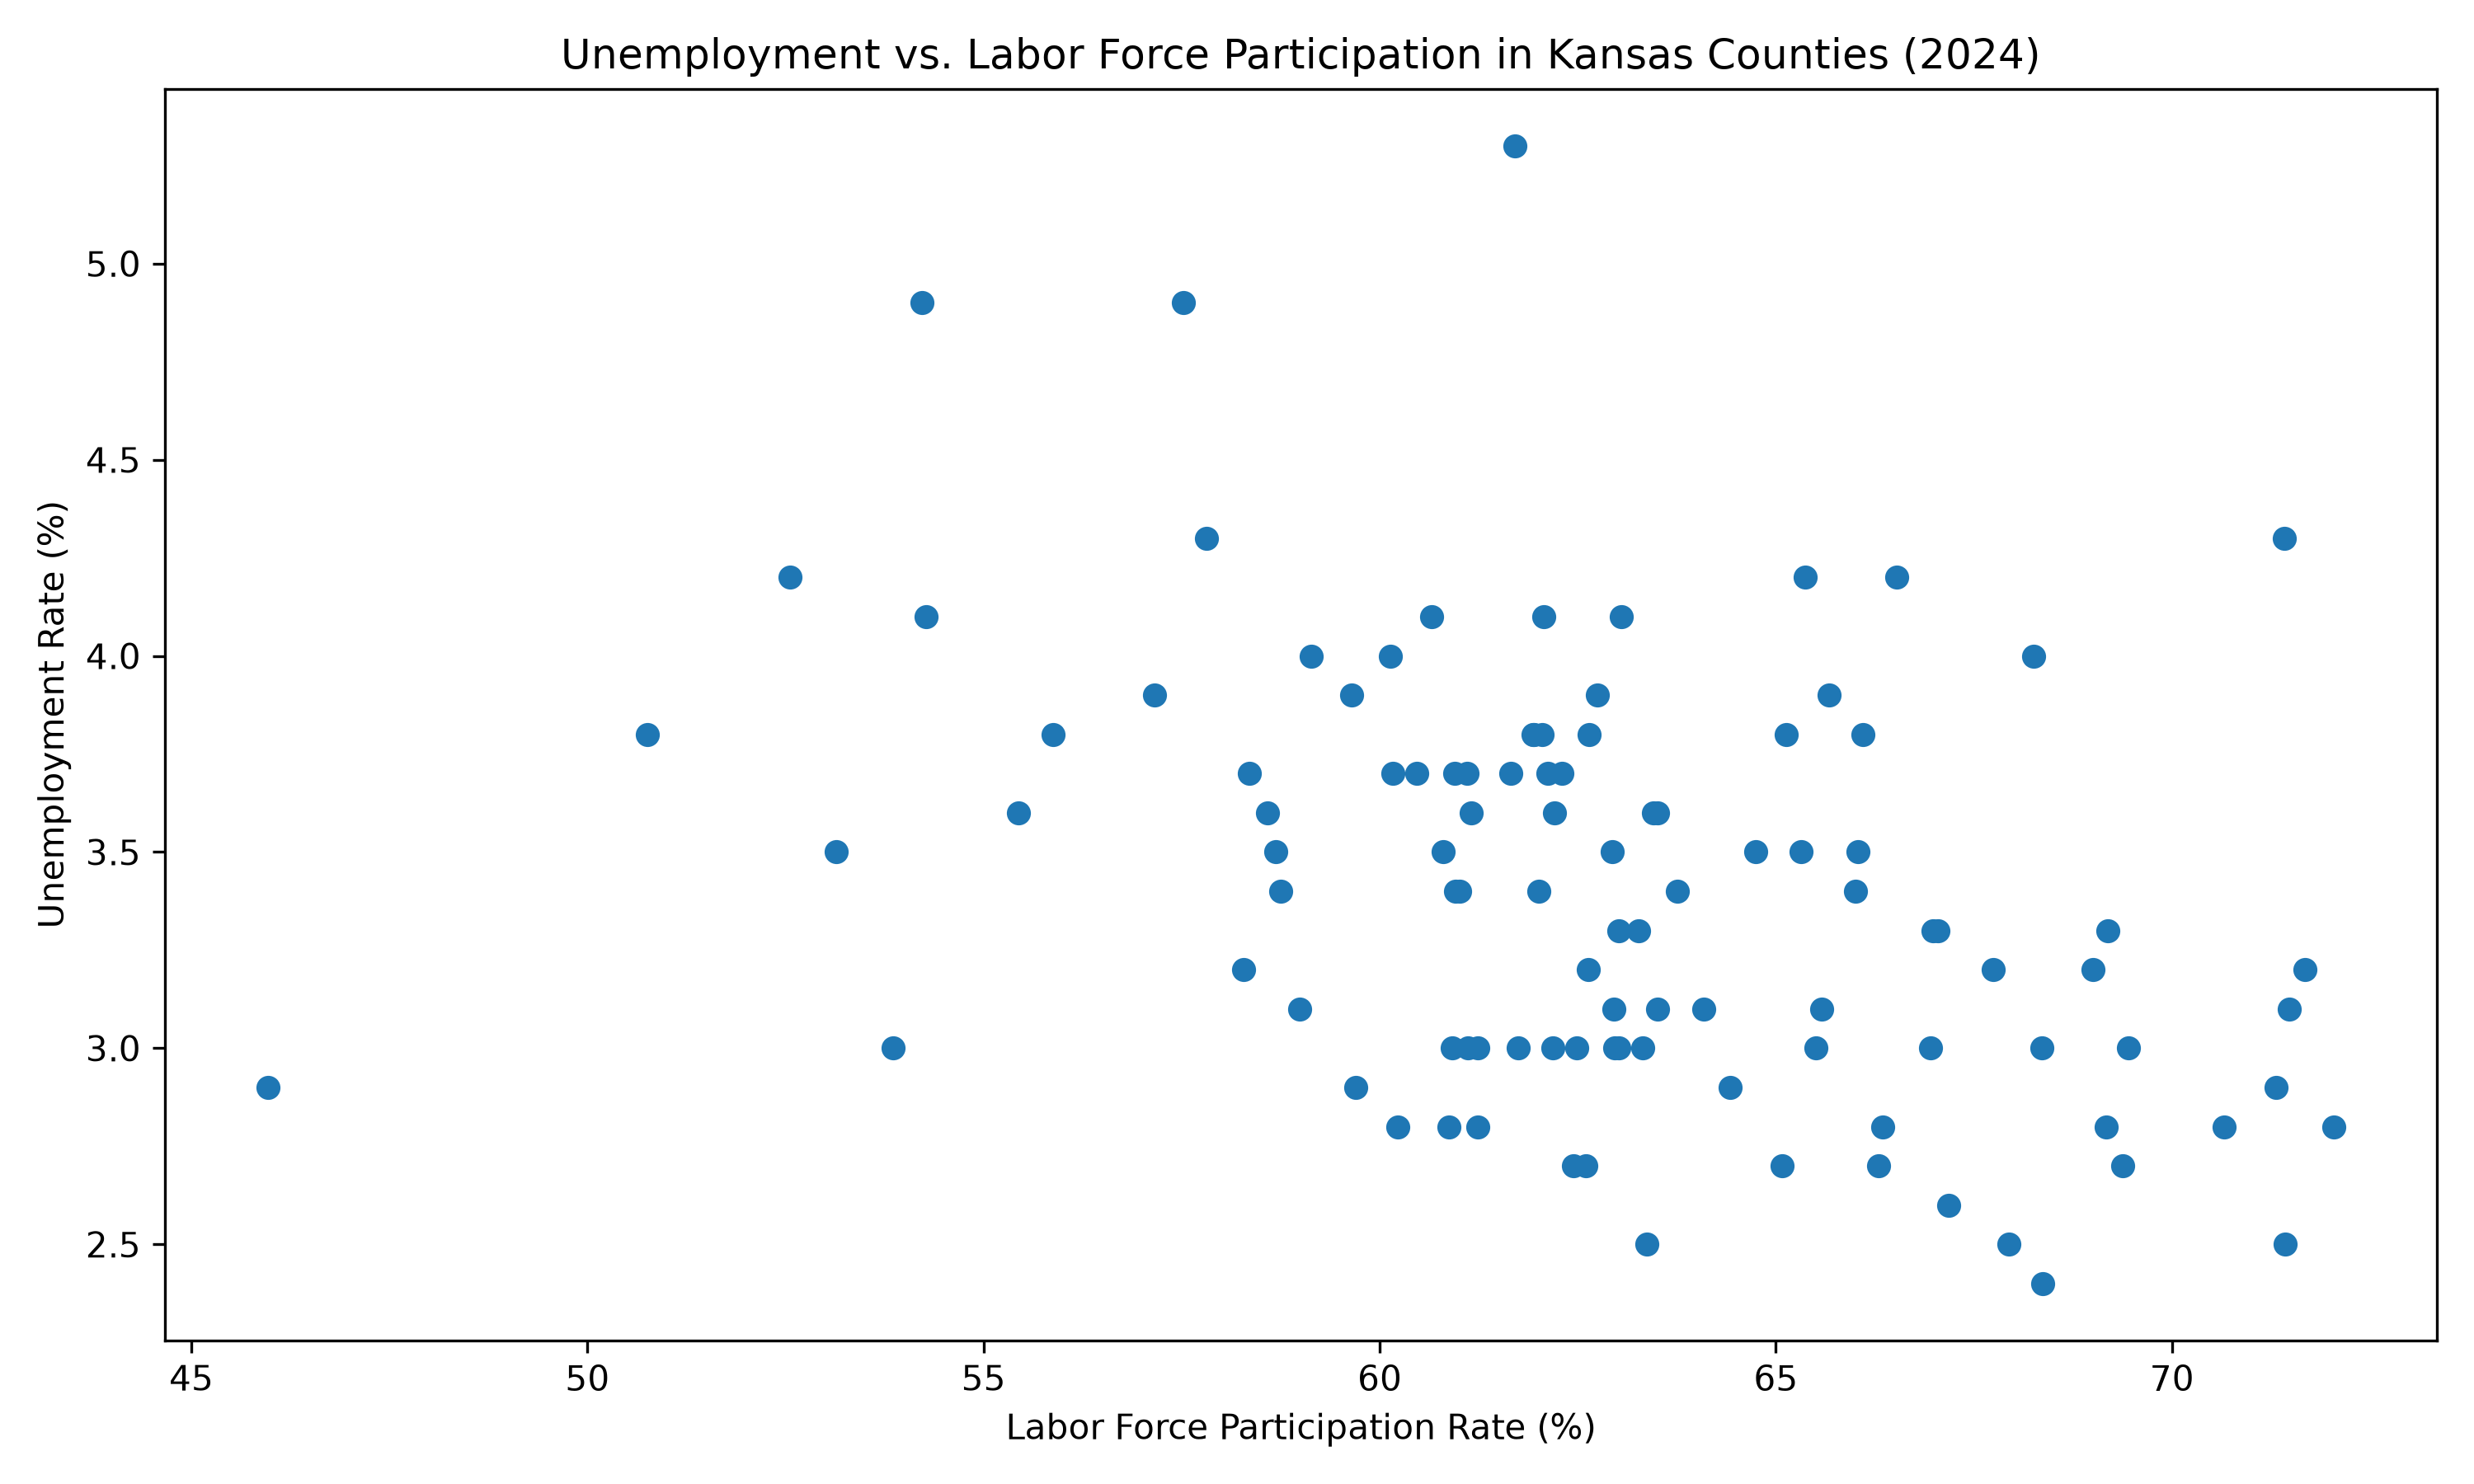

In [26]:
# Display unemployment vs. labor-force participation chart
display(
    Image(
        filename="../outputs/charts/unemployment_vs_labor_force.png"
    )
)

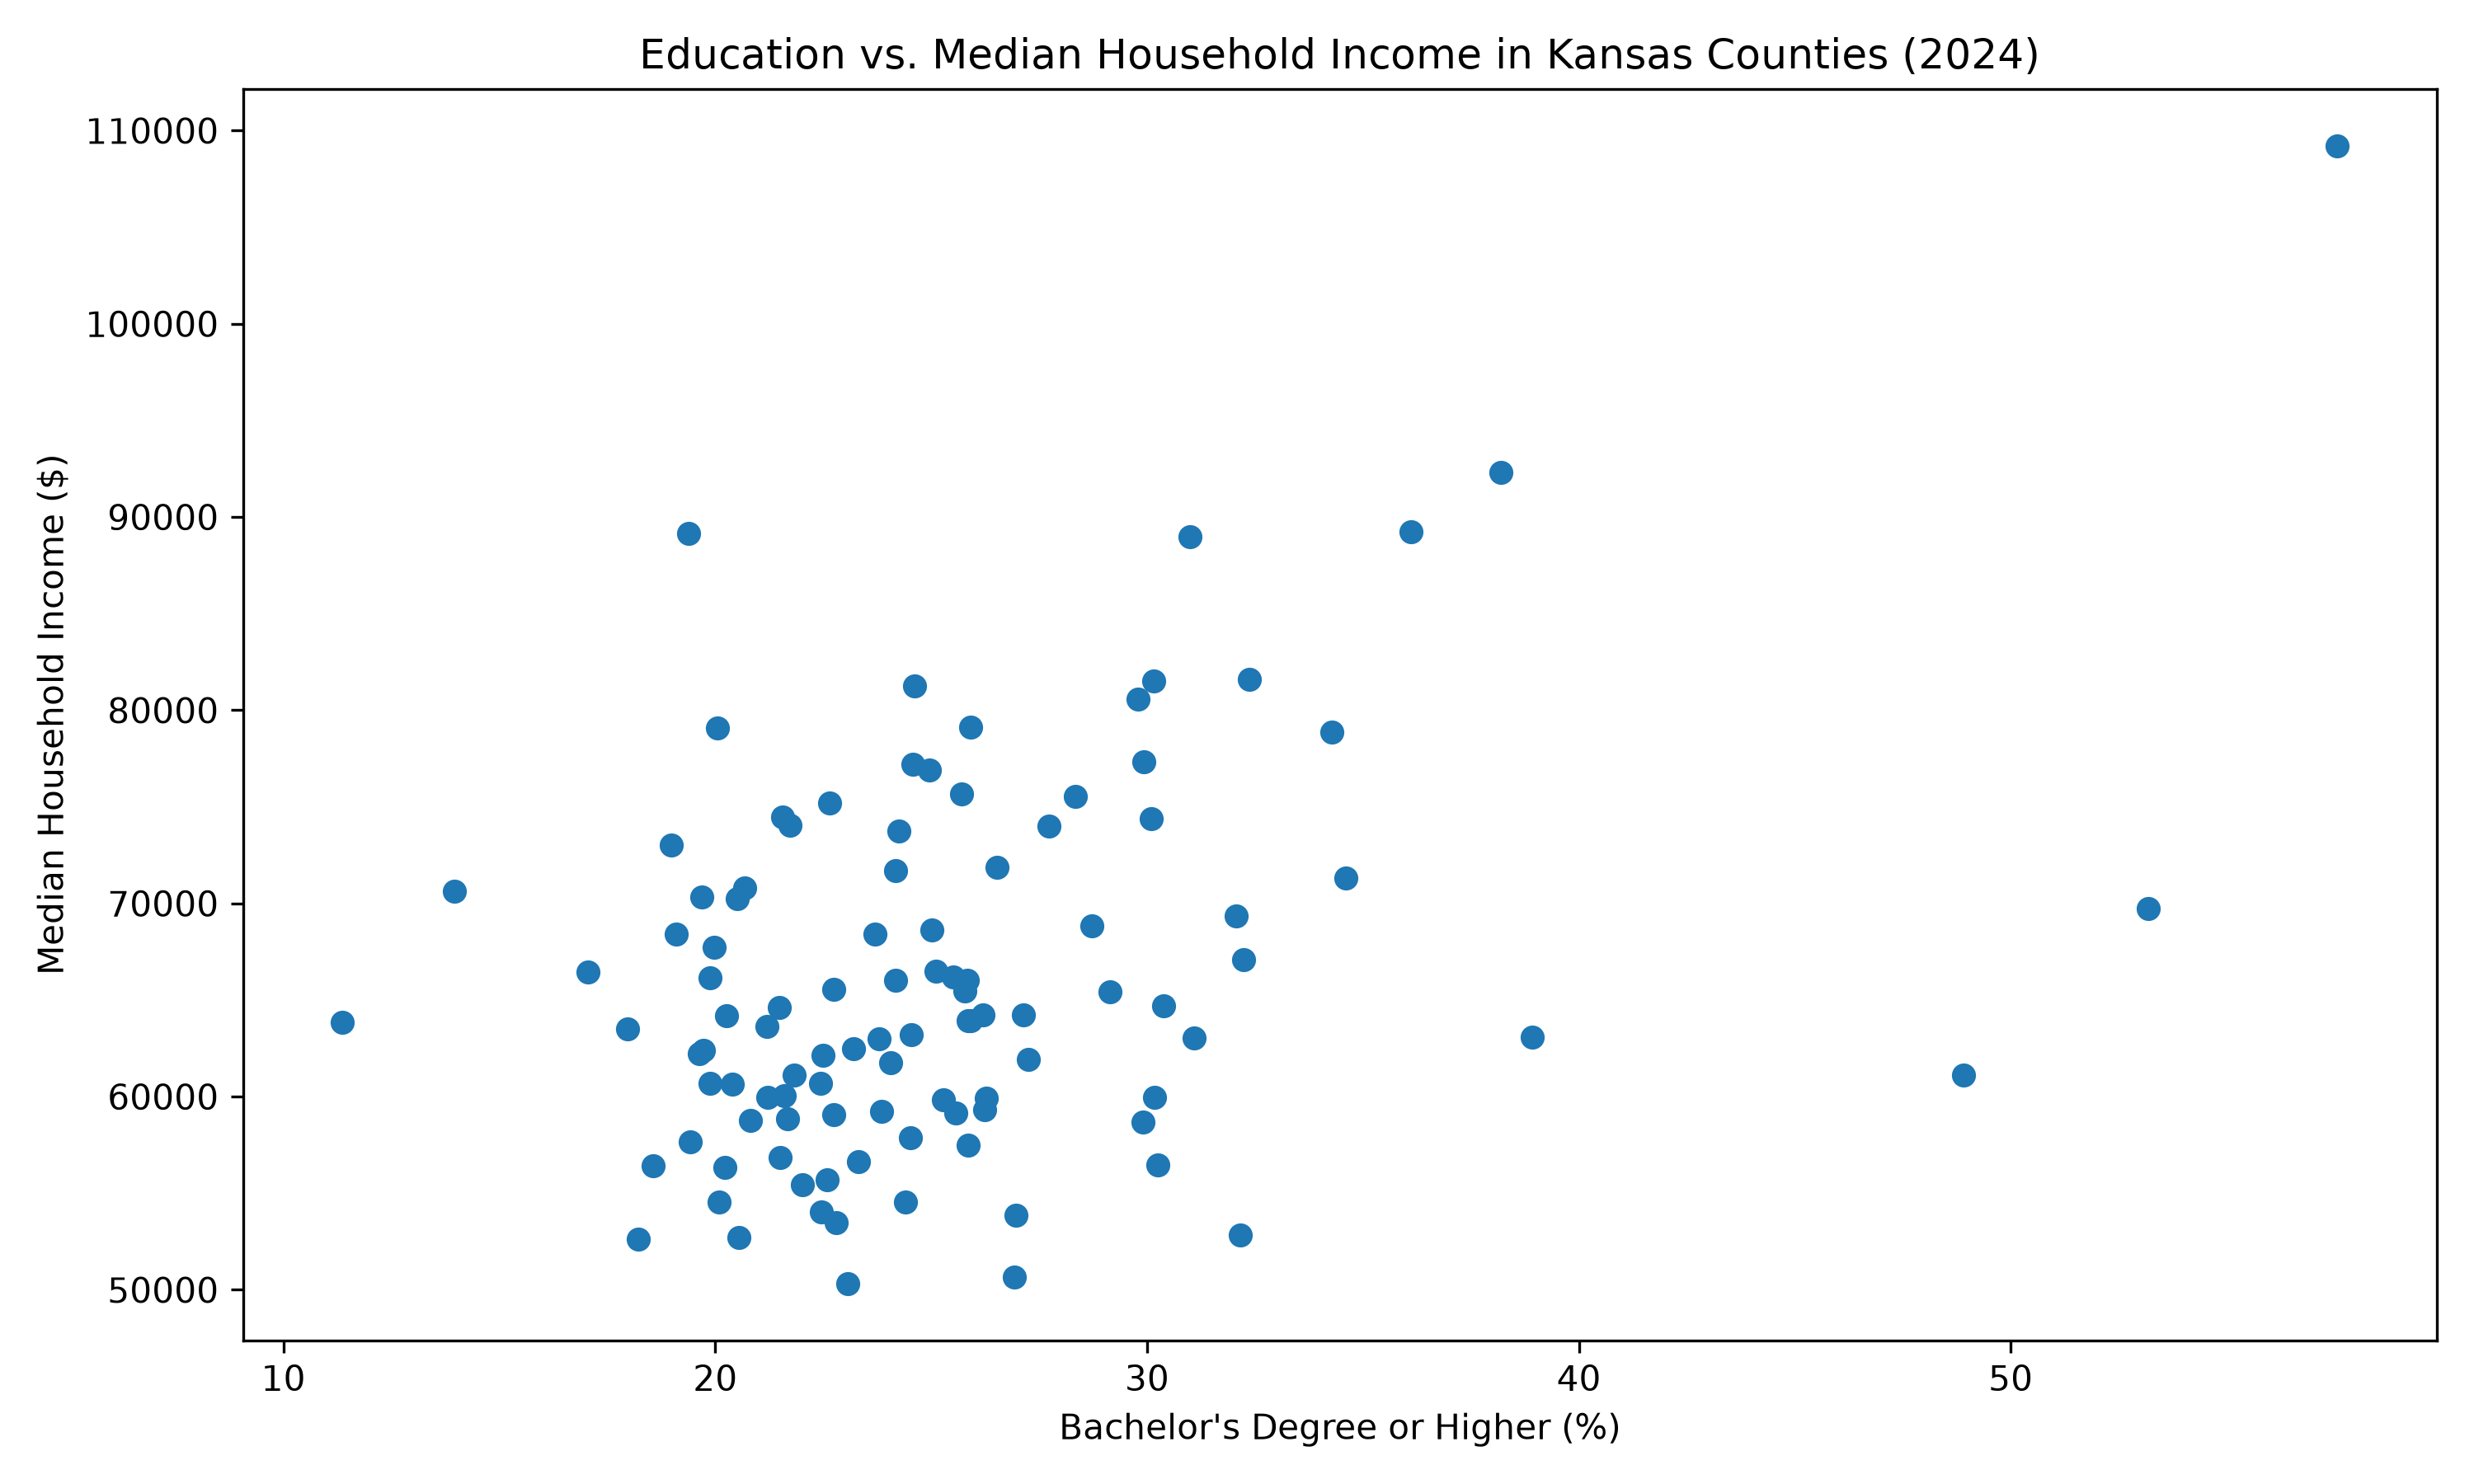

In [27]:
# Display educational attainment vs. household income chart
display(
    Image(
        filename="../outputs/charts/education_vs_income.png"
    )
)

### Educational Attainment and Household Income

The visualization shows a positive relationship between bachelor's-or-higher educational attainment and median household income across Kansas counties.

The correlation analysis found a correlation of **+0.40**, indicating that counties with higher educational attainment tended to have higher median household incomes.

For example, Johnson County had the highest bachelor's-or-higher rate among the counties identified in the ranking analysis at **57.56%**, along with a median household income of **$109,208**.

However, educational attainment was not statistically significant as an independent predictor of unemployment in the multiple regression model (**p = 0.848**). This demonstrates an important distinction: education may be associated with household income while not showing a statistically significant independent association with unemployment in this particular regression specification.

These findings represent county-level associations and do not establish causal relationships.

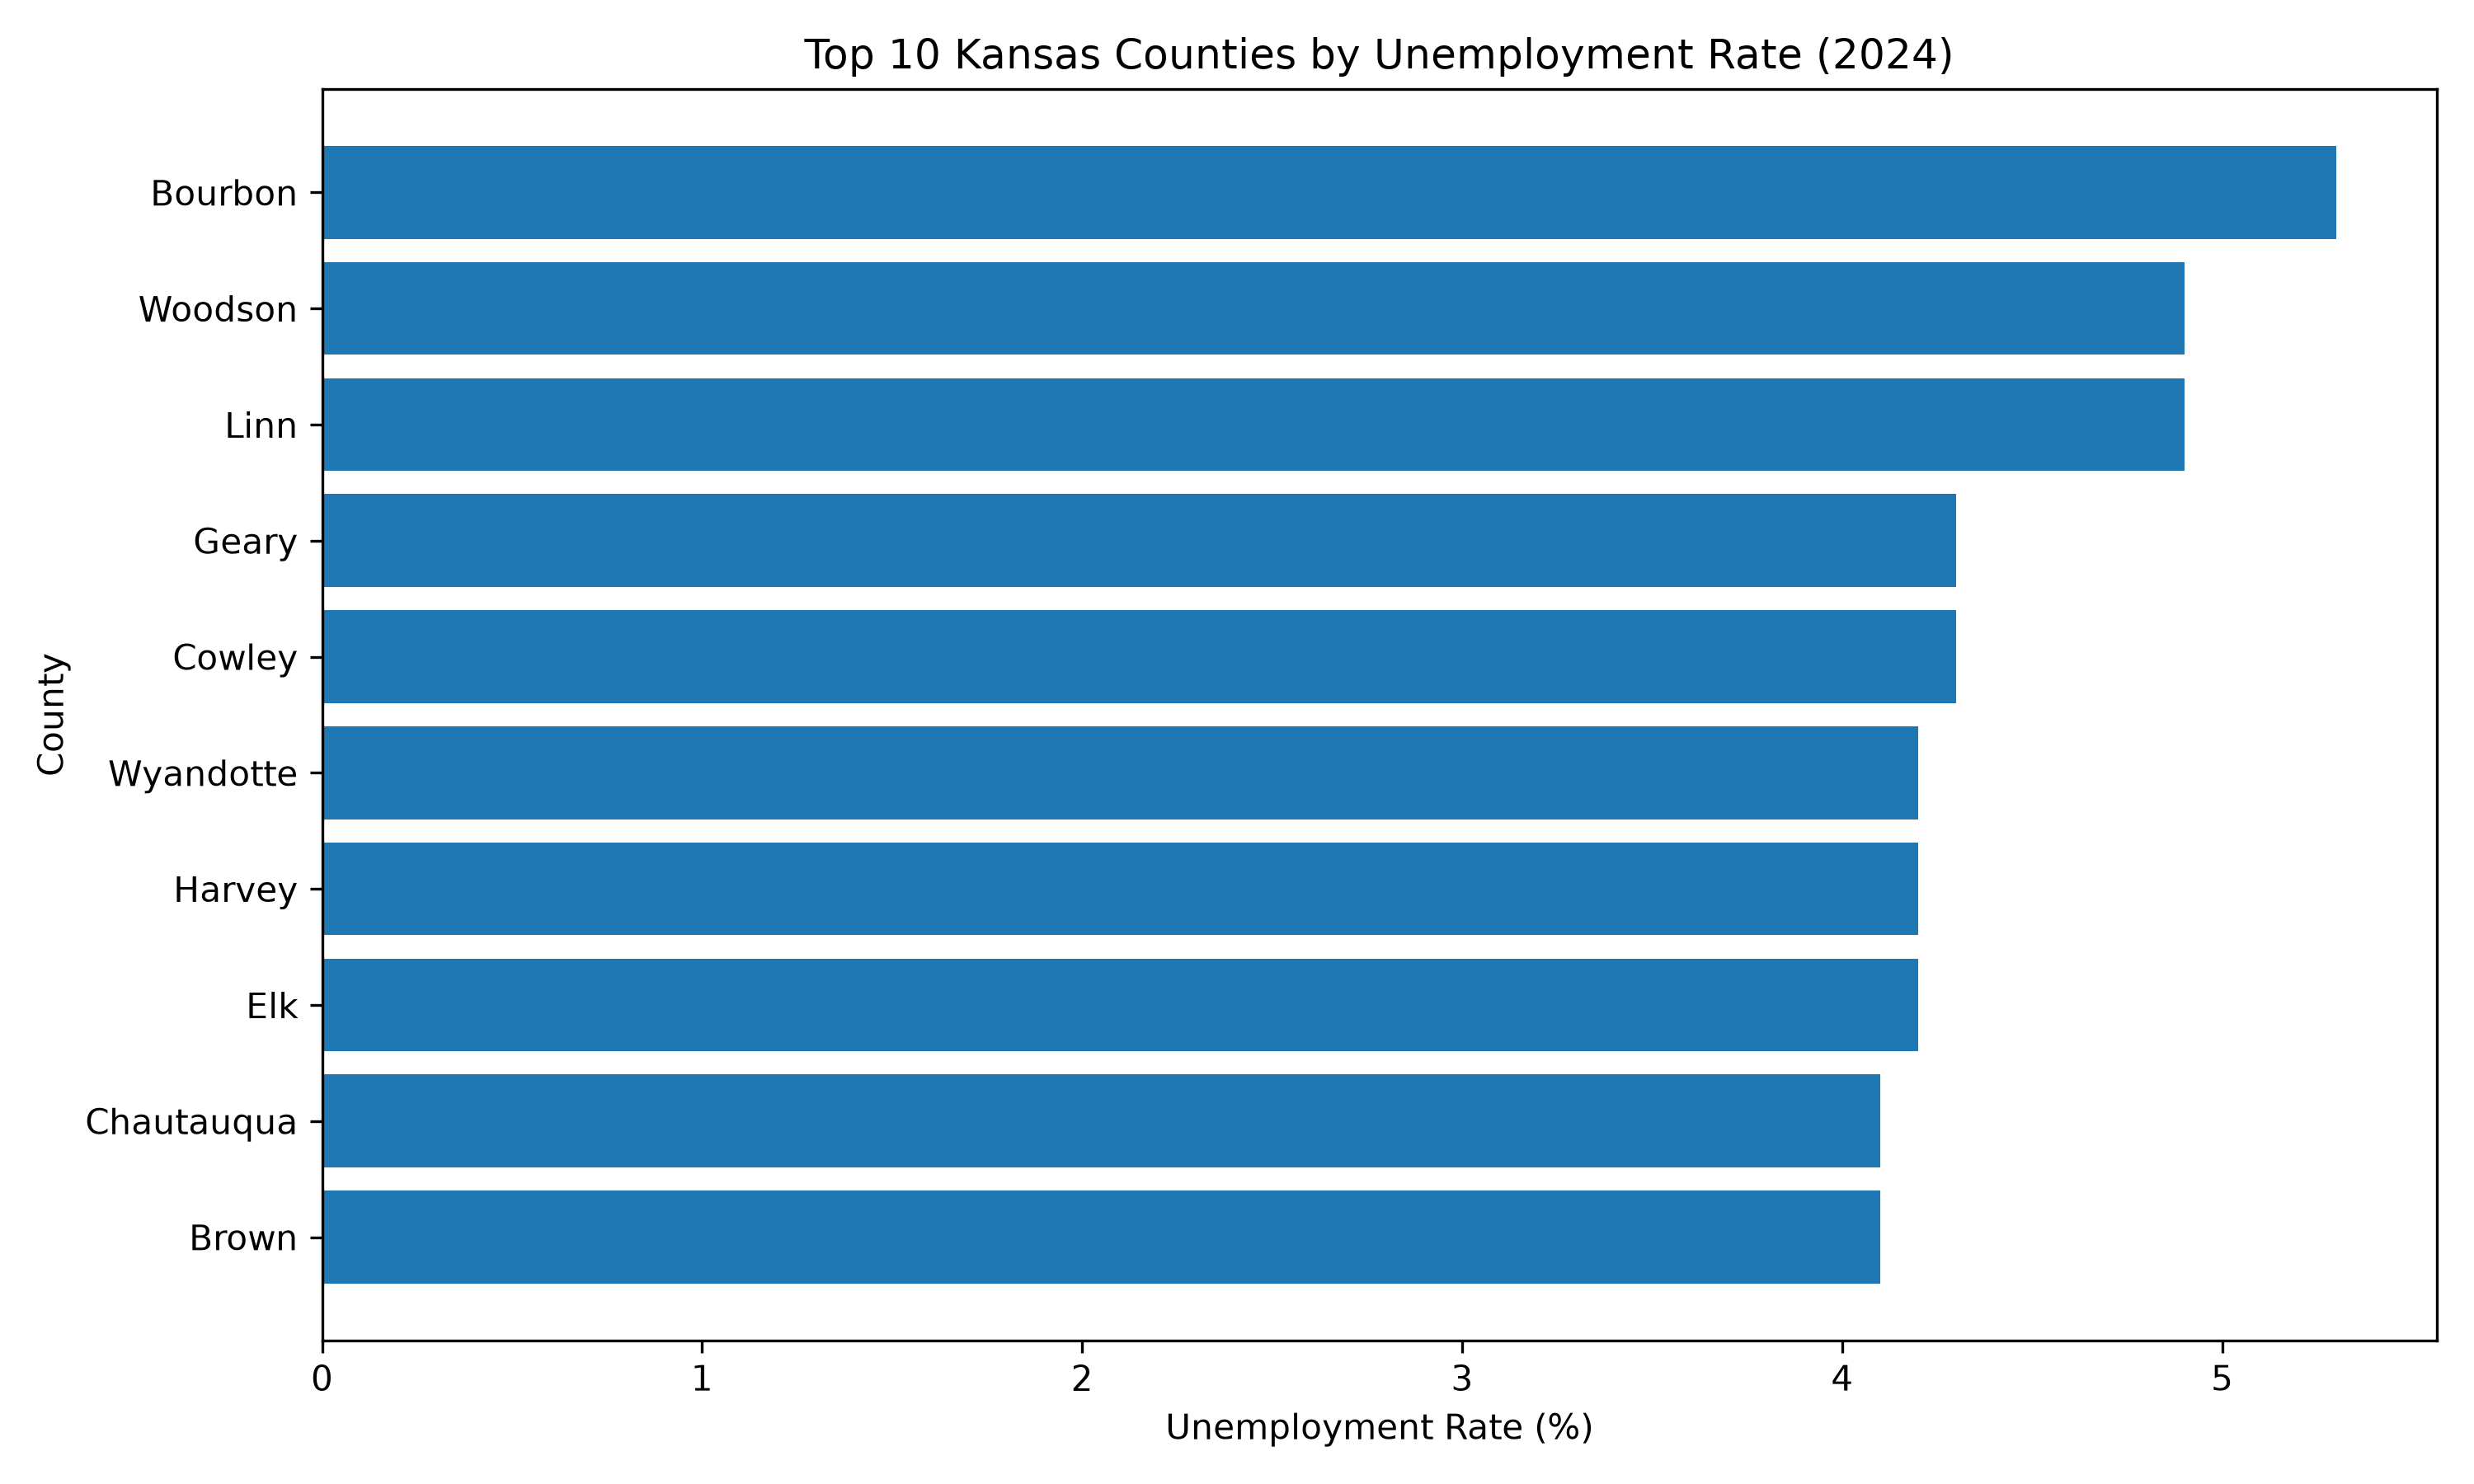

In [28]:
# Display the Top 10 Kansas counties by unemployment rate
display(
    Image(
        filename="../outputs/charts/top_10_unemployment.png"
    )
)

### Counties with the Highest Unemployment Rates

The county ranking shows that unemployment conditions varied considerably across Kansas in the 2024 BLS LAUS data.

**Bourbon County** had the highest unemployment rate at **5.3%**, followed by **Woodson County** and **Linn County**, both at **4.9%**.

The average unemployment rate across all 105 counties was approximately **3.4%**, meaning the counties at the top of the ranking were notably above the county average.

Several counties with relatively high unemployment also appeared in the earlier SQL analysis of counties with both above-average unemployment and above-average poverty. This demonstrates the value of examining multiple economic indicators rather than relying on unemployment alone.

These county rankings are descriptive and identify areas that may warrant further investigation; they do not by themselves explain why unemployment differs across counties.

## SQL Analysis

The cleaned county-level dataset was loaded into a SQLite database to demonstrate SQL-based analysis.

The SQL analysis focused on four business and policy-oriented questions:

1. Which Kansas counties had the highest unemployment rates?
2. Which counties had both above-average unemployment and above-average poverty?
3. Which counties had the lowest labor-force participation rates?
4. Which counties had the highest bachelor's-or-higher educational attainment rates, and what were their median household incomes?

SQL complements the Python analysis by demonstrating how structured queries can be used to filter, rank, and compare county-level economic indicators.

In [29]:
import sqlite3

# Connect to the project SQLite database
connection = sqlite3.connect(
    "../data/processed/kansas_economic_workforce.db"
)

# SQL query: Top 10 counties by unemployment rate
query = """
SELECT
    county_name,
    unemployment_rate
FROM kansas_county_economic_data
ORDER BY unemployment_rate DESC, county_name ASC
LIMIT 10;
"""

# Run the SQL query and display the results
sql_top_unemployment = pd.read_sql_query(query, connection)

sql_top_unemployment

,county_name,unemployment_rate
0,"Bourbon County, Kansas",5.3
1,"Linn County, Kansas",4.9
2,"Woodson County, Kansas",4.9
3,"Cowley County, Kansas",4.3
4,"Geary County, Kansas",4.3
5,"Elk County, Kansas",4.2
6,"Harvey County, Kansas",4.2
7,"Wyandotte County, Kansas",4.2
8,"Brown County, Kansas",4.1
9,"Chautauqua County, Kansas",4.1


In [30]:
# SQL query: Counties with above-average unemployment
# and above-average poverty

query = """
SELECT
    county_name,
    unemployment_rate,
    poverty_rate
FROM kansas_county_economic_data
WHERE unemployment_rate > (
    SELECT AVG(unemployment_rate)
    FROM kansas_county_economic_data
)
AND poverty_rate > (
    SELECT AVG(poverty_rate)
    FROM kansas_county_economic_data
)
ORDER BY unemployment_rate DESC, poverty_rate DESC;
"""

sql_high_unemployment_poverty = pd.read_sql_query(
    query,
    connection
)

sql_high_unemployment_poverty

,county_name,unemployment_rate,poverty_rate
0,"Bourbon County, Kansas",5.3,13.64
1,"Woodson County, Kansas",4.9,12.36
2,"Geary County, Kansas",4.3,18.01
3,"Cowley County, Kansas",4.3,14.26
4,"Wyandotte County, Kansas",4.2,15.76
5,"Wilson County, Kansas",4.1,15.48
6,"Chautauqua County, Kansas",4.1,14.92
7,"Brown County, Kansas",4.1,13.76
8,"Lincoln County, Kansas",4.1,11.34
9,"Russell County, Kansas",4.0,14.69


### SQL Findings: Unemployment and Poverty

The SQL analysis identified Kansas counties with both above-average unemployment and above-average poverty.

Examples included:

- Bourbon County
- Woodson County
- Geary County
- Cowley County
- Wyandotte County
- Wilson County
- Chautauqua County
- Brown County

This combined screening is more informative than ranking unemployment alone because it identifies counties experiencing challenges across multiple economic indicators.

The SQL approach also demonstrates how subqueries can be used to compare each county with statewide county-level averages and isolate areas that may warrant additional investigation.

In [31]:
# SQL query: Counties with the lowest labor-force participation rates

query = """
SELECT
    county_name,
    labor_force_participation_rate,
    unemployment_rate,
    poverty_rate
FROM kansas_county_economic_data
ORDER BY labor_force_participation_rate ASC, county_name ASC
LIMIT 10;
"""

sql_lowest_participation = pd.read_sql_query(
    query,
    connection
)

sql_lowest_participation

,county_name,labor_force_participation_rate,unemployment_rate,poverty_rate
0,"Norton County, Kansas",45.97,2.9,7.20
1,"Ellsworth County, Kansas",50.76,3.8,10.37
2,"Elk County, Kansas",52.56,4.2,10.37
3,"Morton County, Kansas",53.14,3.5,14.77
4,"Pawnee County, Kansas",53.86,3.0,11.52
5,"Woodson County, Kansas",54.22,4.9,12.36
6,"Chautauqua County, Kansas",54.27,4.1,14.92
7,"Harper County, Kansas",55.44,3.6,17.30
8,"Chase County, Kansas",55.88,3.8,8.35
9,"Montgomery County, Kansas",57.16,3.9,15.92


### SQL Findings: Labor-Force Participation

The SQL results show that some Kansas counties had relatively low labor-force participation even when their unemployment rates were not especially high.

For example:

- **Norton County** had the lowest labor-force participation rate in the analysis at **45.97%**, while its unemployment rate was **2.9%**.
- **Ellsworth County** had labor-force participation of **50.76%** and unemployment of **3.8%**.
- **Woodson County** combined relatively low labor-force participation (**54.22%**) with relatively high unemployment (**4.9%**).

This illustrates why unemployment should not be interpreted by itself. A county can have a low unemployment rate while also having a relatively small share of its population participating in the labor force.

Examining both measures provides a more complete view of local workforce conditions.

In [32]:
# SQL query: Counties with the highest educational attainment

query = """
SELECT
    county_name,
    bachelors_or_higher_rate,
    median_household_income
FROM kansas_county_economic_data
ORDER BY bachelors_or_higher_rate DESC,
         median_household_income DESC
LIMIT 10;
"""

sql_education_income = pd.read_sql_query(
    query,
    connection
)

sql_education_income

,county_name,bachelors_or_higher_rate,median_household_income
0,"Johnson County, Kansas",57.56,109208
1,"Douglas County, Kansas",53.19,69746
2,"Riley County, Kansas",48.91,61098
3,"Ellis County, Kansas",38.91,63084
4,"Pottawatomie County, Kansas",38.19,92325
5,"Leavenworth County, Kansas",36.12,89218
6,"Thomas County, Kansas",34.61,71325
7,"McPherson County, Kansas",34.27,78851
8,"Butler County, Kansas",32.37,81610
9,"Shawnee County, Kansas",32.23,67104


### SQL Findings: Educational Attainment and Income

The SQL ranking shows that counties with the highest educational attainment rates varied considerably in household income.

- **Johnson County** had the highest bachelor's-or-higher attainment rate at **57.56%** and a median household income of **$109,208**.
- **Douglas County** had an attainment rate of **53.19%** and median household income of **$69,746**.
- **Riley County** had an attainment rate of **48.91%** and median household income of **$61,098**.
- **Pottawatomie County** had an attainment rate of **38.19%** and median household income of **$92,325**.

The ranking is based primarily on educational attainment rather than household income. Therefore, these results should not be interpreted as a ranking of the highest-income Kansas counties.

Combined with the correlation analysis, the results show a positive county-level association between educational attainment and median household income, while also showing that counties with similar educational attainment levels can have different income levels.

## Key Findings

The analysis identified several important patterns in economic and workforce conditions across Kansas counties.

1. **Unemployment varied considerably across counties.**  
   The average county unemployment rate was approximately **3.4%**, while Bourbon County had the highest rate at **5.3%**. Woodson and Linn counties followed at **4.9%**.

2. **Labor-force participation was negatively associated with unemployment.**  
   The correlation between labor-force participation and unemployment was **-0.35**. In the multiple regression model, labor-force participation was the only predictor statistically significant at the 5% level (**coefficient = -0.0378, p = 0.002**).

3. **Low unemployment did not always indicate strong labor-force participation.**  
   Norton County had an unemployment rate of only **2.9%**, but its labor-force participation rate was **45.97%**, the lowest among the counties analyzed.

4. **Higher household income was associated with lower poverty.**  
   Poverty and median household income had a correlation of **-0.49**, one of the stronger relationships observed in the analysis.

5. **Educational attainment was positively associated with household income.**  
   Bachelor's-or-higher attainment and median household income had a correlation of **+0.40**. Johnson County had the highest educational attainment rate in the ranking at **57.56%** and a median household income of **$109,208**.

6. **The regression model explained only part of the differences in unemployment.**  
   The model had an **R² of 0.175**, indicating that the four included predictors explained approximately **17.5%** of the variation in county unemployment rates. Other economic, demographic, geographic, and industry-related factors may account for additional variation.

Overall, the findings demonstrate the importance of examining multiple indicators when evaluating local workforce conditions rather than relying on unemployment alone.

## Limitations

Several limitations should be considered when interpreting this analysis.

- **County-level analysis:** The project analyzes aggregated county data. Relationships observed at the county level should not be assumed to describe individual residents.

- **Cross-sectional analysis:** The analysis focuses primarily on 2024 conditions. It identifies differences and associations across counties but does not measure how these relationships change over time.

- **Correlation does not establish causation:** Relationships among unemployment, poverty, income, education, and labor-force participation represent statistical associations and should not be interpreted as causal effects.

- **Limited regression predictors:** The regression model includes four predictors and explains approximately **17.5%** of the variation in county unemployment rates. Other factors such as industry composition, demographics, commuting patterns, major employers, and local economic conditions were not included.

- **Different source methodologies:** Census ACS and BLS LAUS measures are produced using different methodologies. Although FIPS codes provide reliable geographic matching, similarly named economic measures from the two sources are not necessarily constructed in exactly the same way.

- **ACS estimates:** ACS values are survey-based estimates and are subject to sampling and measurement uncertainty.

These limitations mean the results are best used as an exploratory assessment of Kansas county economic and workforce conditions rather than as evidence of causal relationships.

## Conclusion

This project examined economic and workforce conditions across all 105 Kansas counties using 2024 Census ACS and BLS LAUS data.

The analysis showed meaningful differences in unemployment, poverty, household income, educational attainment, and labor-force participation across counties. Correlation analysis identified several relationships among these indicators, while multiple linear regression showed that labor-force participation had the clearest independent association with unemployment in the model.

The SQL analysis provided additional county-level screening by identifying areas with relatively high unemployment and poverty, low labor-force participation, and higher educational attainment.

Overall, the project demonstrates how **Python, SQL, statistical analysis, and data visualization** can be combined to investigate workforce and economic conditions. The results can be used as a starting point for identifying counties that may warrant further analysis, while recognizing that the findings are descriptive and do not establish causal relationships.